In [42]:
#%load_ext autoreload
#%autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map

In [45]:
data_dir = pathlib.Path('../data/raw/sebastian_sun_spots')  


# Data Sebastián análisis

## pruebas de funciones

In [46]:
DS03_dir = data_dir.joinpath('DS03')
cube_continuum = DS03_dir / 'cube_continuum.fits'
cube_dopplergram = DS03_dir / 'cube_dopplergram_corrected.fits'
cube_magnetogram = DS03_dir / 'cube_magnetogram.fits'


In [47]:
#list of all the fits files in the data directory
fits_files = list(DS03_dir.glob('*.fits'))
fits_files

[PosixPath('../data/raw/sebastian_sun_spots/DS03/disambig_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_magnetogram.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_xcoord.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram_qsun.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/azimuth_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_continuum.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_ycoord.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_continuum_qsun.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/units.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/Dopplergram_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram_corrected.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_mu.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/inclination_r

In [48]:
# Open the corrected Continuum cube — it has a minimal IDL header
cube_path = DS03_dir / 'cube_continuum.fits'
with fits.open(cube_path) as hdul:
    cube_header = hdul[0].header
    cube_shape  = hdul[0].data.shape  # (time, y, x)
    cube_data   = hdul[0].data
print('=== Continuum cube header (IDL format) ===')
print(repr(cube_header))

=== Continuum cube header (IDL format) ===
SIMPLE  =                    T / Written by IDL:  Thu Mar 11 09:16:25 2021      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  239 /                                                
NAXIS2  =                  240 /                                                
NAXIS3  =                 1084 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2021-03-11'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    


In [113]:
# Open the corrected Dopplergram cube — it has a minimal IDL header
cube_path = DS03_dir / 'cube_dopplergram_corrected.fits'
with fits.open(cube_path) as hdul:
    cube_header = hdul[0].header
    cube_shape  = hdul[0].data.shape  # (time, y, x)
    cube_data   = hdul[0].data

print('=== cube_dopplergram_corrected.fits header ===')
print(repr(cube_header))
print(f'\nData shape (time, y, x): {cube_shape}')

# Full spatial/WCS metadata lives in Dopplergram_ref.fits
with fits.open(DS03_dir / 'Dopplergram_ref.fits') as hdul:
    ref_header = hdul[0].header

print('\n=== Dopplergram_ref.fits header (spatial metadata) ===')
print(repr(ref_header))


2026-06-18 11:52:08 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.


=== cube_dopplergram_corrected.fits header ===
SIMPLE  =                    T / Written by IDL:  Fri Mar 12 07:31:17 2021      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  239 /                                                
NAXIS2  =                  240 /                                                
NAXIS3  =                 1084 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2021-03-12'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    

Data shape (time, y, x): (1084, 240, 239)

=== Dopplergram_ref.fits header (spatial metadata) ===
SIMPLE  =                    T / Written by 

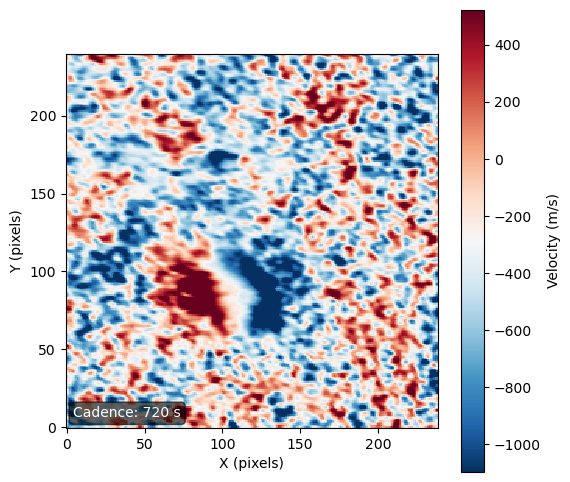

In [11]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

CADENCE_S = 720  # seconds per frame (HMI 720-s series)
STEP = 5         # subsample: every 5th frame keeps the animation manageable

# Mask fill values (~-1.18e+29) and any extreme outliers
cube_masked = np.where(np.abs(cube_data) > 1e4, np.nan, cube_data.astype(float))

frames_idx = np.arange(0, cube_masked.shape[0], STEP)
vmin, vmax = np.nanpercentile(cube_masked, [2, 98])

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cube_masked[0], origin='lower', cmap='RdBu_r',
               vmin=vmin, vmax=vmax, interpolation='nearest')
fig.colorbar(im, ax=ax, label='Velocity (m/s)')

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

# Fixed cadence label in bottom-left corner
ax.text(0.02, 0.02, f'Cadence: {CADENCE_S} s',
        transform=ax.transAxes, color='white', fontsize=10,
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

title = ax.set_title('')

def _update(i):
    t = frames_idx[i]
    im.set_data(cube_masked[t])
    elapsed_h = t * CADENCE_S / 3600
    title.set_text(f'SDO/HMI Dopplergram  —  frame {t:04d}  |  t = {elapsed_h:.2f} h')
    return im, title

#anim = FuncAnimation(fig, _update, frames=len(frames_idx), interval=80, blit=True)
#plt.close(fig)

#HTML(anim.to_jshtml())

In [12]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
def create_dopplergram_animation():
    CADENCE_S = 720  # seconds per frame (HMI 720-s series)
    STEP = 5         # subsample: every 5th frame keeps the animation manageable

    # Mask fill values (~-1.18e+29) and any extreme outliers
    cube_masked = np.where(np.abs(cube_data) > 1e4, np.nan, cube_data.astype(float))

    frames_idx = np.arange(0, cube_masked.shape[0], STEP)
    vmin, vmax = np.nanpercentile(cube_masked, [2, 98])

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cube_masked[0], origin='lower', cmap='RdBu_r',
                vmin=vmin, vmax=vmax, interpolation='nearest')
    fig.colorbar(im, ax=ax, label='Velocity (m/s)')

    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

    # Fixed cadence label in bottom-left corner
    ax.text(0.02, 0.02, f'Cadence: {CADENCE_S} s',
            transform=ax.transAxes, color='white', fontsize=10,
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

    title = ax.set_title('')

    def _update(i):
        t = frames_idx[i]
        im.set_data(cube_masked[t])
        elapsed_h = t * CADENCE_S / 3600
        title.set_text(f'SDO/HMI Dopplergram  —  frame {t:04d}  |  t = {elapsed_h:.2f} h')
        return im, title

    anim = FuncAnimation(fig, _update, frames=len(frames_idx), interval=80, blit=True)
    plt.close(fig)



    HTML(anim.to_jshtml())
#create_dopplergram_animation();

## pipeline general con DS03

In [4]:
# compute cadence 

# read .sav file 

DS01_dir = data_dir.joinpath('DS01')

from scipy.io import readsav

sav_data = readsav(DS01_dir / 'cube_continuum_coords2times.sav')
sav_data.keys()


dict_keys(['hdrs', 'times', 'xd', 'yd'])

In [5]:
import datetime

result = sav_data['times'].flatten().astype(str)

times = [datetime.datetime.strptime(time, '%d-%b-%Y %H:%M:%S.%f') for time in result]
# compute cadence from times
time_diffs = np.diff(times)
time_diffs_seconds = np.array([td.total_seconds() for td in time_diffs])
time_diffs_seconds

array([720., 720., 720., ..., 720., 720., 720.], shape=(1066,))

In [8]:
FILL = 1e6          # fill-value sentinel threshold
CADENCE_S = 720     # seconds per frame

# ── load the three channels ──────────────────────────────────────────────────
def load_cube(path):
    with fits.open(path) as hdul:
        arr = hdul[0].data.astype(float)
    return np.where(np.abs(arr) > FILL, np.nan, arr)

cube_cont = load_cube(DS01_dir / 'cube_continuum.fits')
cube_mag  = load_cube(DS01_dir / 'cube_magnetogram.fits')
cube_dop  = load_cube(DS01_dir / 'cube_dopplergram_corrected.fits')
cube_dop_qsun = load_cube(DS01_dir / 'cube_dopplergram_qsun.fits')
cube_mag_qsun = load_cube(DS01_dir / 'cube_magnetogram_qsun.fits')
cube_mu = load_cube(DS01_dir/'cube_mu.fits')

print('continuum  :', cube_cont.shape, f'  range [{np.nanmin(cube_cont):.0f}, {np.nanmax(cube_cont):.0f}]')
print('magnetogram:', cube_mag.shape,  f'  range [{np.nanmin(cube_mag):.0f}, {np.nanmax(cube_mag):.0f}] G')
print('dopplergram:', cube_dop.shape,  f'  range [{np.nanmin(cube_dop):.0f}, {np.nanmax(cube_dop):.0f}] m/s')
print('dopplergram_qsun:', cube_dop_qsun.shape,  f'  range [{np.nanmin(cube_dop_qsun):.0f}, {np.nanmax(cube_dop_qsun):.0f}] m/s')
print('magnetogram_qsun:', cube_mag_qsun.shape,  f'  range [{np.nanmin(cube_mag_qsun):.0f}, {np.nanmax(cube_mag_qsun):.0f}] G')
print('mu sun:', cube_mu.shape,  f'  range [{np.nanmin(cube_mu):.0f}, {np.nanmax(cube_mu):.0f}] G')

continuum  : (1067, 239, 239)   range [5602, 69861]
magnetogram: (1067, 239, 239)   range [-1057, 2397] G
dopplergram: (1067, 239, 239)   range [-3657, 3289] m/s
dopplergram_qsun: (1067, 60, 60)   range [-4634, 4095] m/s
magnetogram_qsun: (1067, 60, 60)   range [-665, 640] G
mu sun: (1067, 239, 239)   range [0, 1] G


In [9]:
CONT_THRESH_UMB = 30_000   # penumbra: continuum > 30 000 DN
CONT_THRESH_PEM = 50_000   # umbra: continuum < 10 000 DN

# boolean mask (time, y, x) — penumbra pixels at each frame
umbra = (cube_cont < CONT_THRESH_UMB) & np.isfinite(cube_cont)
penumbra = (cube_cont < CONT_THRESH_PEM) & np.isfinite(cube_cont) & ~umbra
both = (cube_cont < CONT_THRESH_PEM) & np.isfinite(cube_cont)  
#quiet_sun = (cube_cont >= CONT_THRESH_UMB) & np.isfinite(cube_cont)

n_t = cube_cont.shape[0]
time_h = np.arange(n_t) * CADENCE_S / 3600   # hours




In [ ]:

#from scipy.ndimage import center_of_mass
## Assuming 'matrix' has the shape (1084, 240, 239)
## This loops through each frame and calculates its 2D center of intensity
#cms = np.array([center_of_mass(penumbra[i]) for i in range(penumbra.shape[0])])

#radius = 50

#filter_matrix = np.zeros_like(penumbra)

#for i in range(penumbra.shape[0]):
#     y, x = cms[i]
#     y, x = int(round(y)), int(round(x))
#     filter_matrix[i, max(0, y-radius):y+radius, max(0, x-radius):x+radius] = True

# crop_penumbra = filter_matrix & penumbra


In [10]:
from scipy import ndimage
import numpy as np


def keep_central_cluster(binary_img, mode='largest'):
    """
    binary_img: 2D numpy array of 0s and 1s
    mode: 'largest' keeps biggest cluster, 'central' keeps cluster nearest image center
    """
    labeled, n = ndimage.label(binary_img)
    if n == 0:
        return binary_img

    if mode == 'largest':
        sizes = ndimage.sum(binary_img, labeled, range(1, n + 1))
        keep = np.argmax(sizes) + 1
    else:  # 'central'
        cy, cx = np.array(binary_img.shape) / 2
        centroids = ndimage.center_of_mass(binary_img, labeled, range(1, n + 1))
        dists = [np.hypot(y - cy, x - cx) for y, x in centroids]
        keep = np.argmin(dists) + 1

    return (labeled == keep).astype(binary_img.dtype)

umbra_cropped = np.array([keep_central_cluster(umbra[i], mode='largest') for i in range(cube_cont.shape[0])], dtype=bool)
penumbra_cropped = np.array([keep_central_cluster(penumbra[i], mode='largest') for i in range(penumbra.shape[0])], dtype=bool)

In [11]:
penumbra = penumbra_cropped
umbra = umbra_cropped

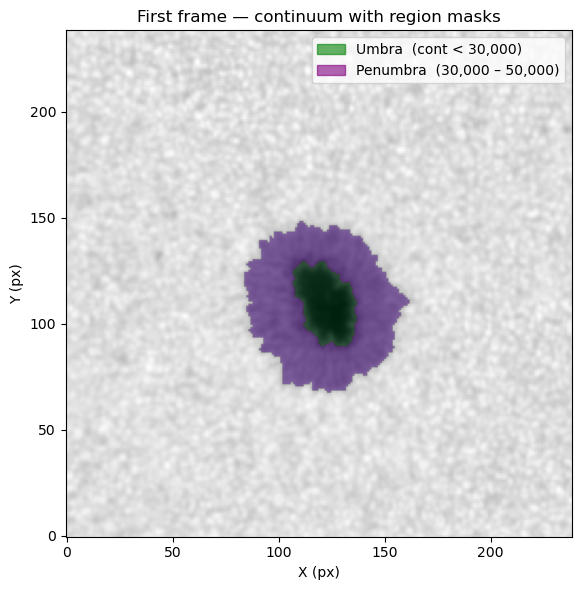

In [12]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 6))

image_idx = 500

ax.imshow(cube_cont[image_idx], cmap='gray', origin='lower')
ax.imshow(np.where(umbra[image_idx],    1.0, np.nan), cmap='Greens',  alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.imshow(np.where(penumbra[image_idx], 1.0, np.nan), cmap='Purples', alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title('First frame — continuum with region masks')
ax.legend(handles=[
    mpatches.Patch(color='green',  alpha=0.6, label=f'Umbra  (cont < {CONT_THRESH_UMB:,})'),
    mpatches.Patch(color='purple', alpha=0.6, label=f'Penumbra  ({CONT_THRESH_UMB:,} – {CONT_THRESH_PEM:,})'),
], loc='upper right')
plt.tight_layout()
plt.show()

### create beter regions for magnetogram

/tmp/ipykernel_29249/604934986.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 700x700 with 2 Axes> than <Figure size 600x600 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)


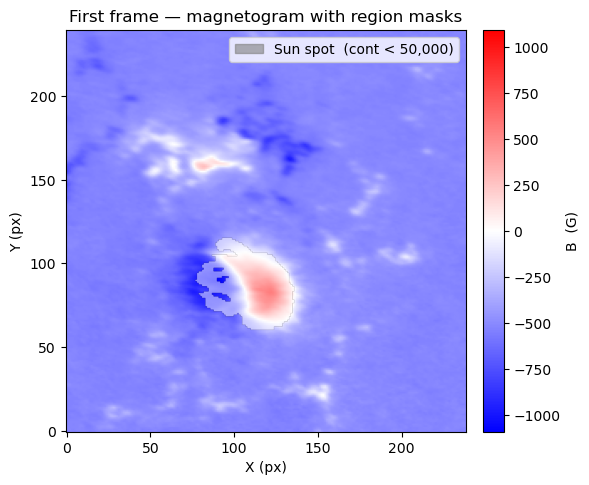

In [55]:
sun_spot = umbra + penumbra

fig, ax = plt.subplots(figsize=(6, 6))

image_idx = 1
fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)

ax.imshow(cube_mag[image_idx], cmap='bwr', origin='lower')
ax.imshow(np.where(sun_spot[image_idx],    1.0, np.nan), cmap='gray',  alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title('First frame — magnetogram with region masks')
ax.legend(handles=[
    mpatches.Patch(color='gray',  alpha=0.6, label=f'Sun spot  (cont < {CONT_THRESH_PEM:,})')
], loc='upper right')
plt.tight_layout()
plt.show()

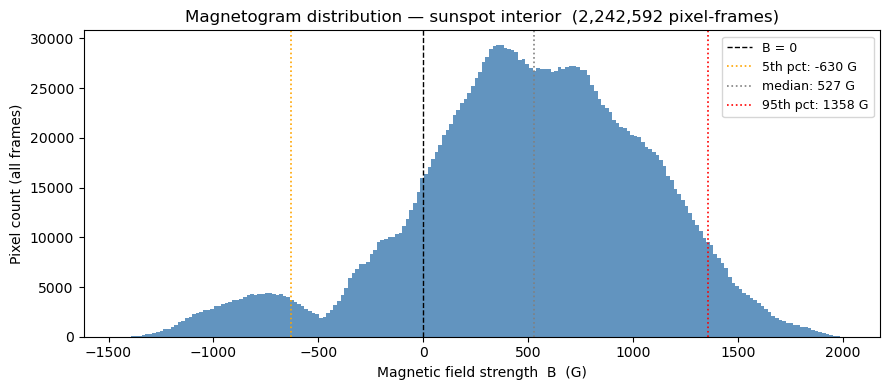

min=-1446  p1=-1035  p5=-630  p25=174  median=527  p75=898  p95=1358  p99=1630  max=2005 G


In [56]:
# create an histogram of all the cube out of all the values of the magnetogram inside the region sunspot
# ── Magnetogram histogram — all pixel values inside the sunspot (all frames) ──
mag_in_spot = cube_mag[both]
mag_in_spot = mag_in_spot[np.isfinite(mag_in_spot)]

p1, p5, p25, p50, p75, p95, p99 = np.nanpercentile(mag_in_spot, [1, 5, 25, 50, 75, 95, 99])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(mag_in_spot, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Magnetic field strength  B  (G)')
ax.set_ylabel('Pixel count (all frames)')
ax.set_title(f'Magnetogram distribution — sunspot interior  ({both.sum():,} pixel-frames)')
ax.axvline(0,   color='black',  lw=1.0, ls='--', label='B = 0')
for val, lbl, col in [(p5, '5th pct', 'orange'), (p50, 'median', 'gray'), (p95, '95th pct', 'red')]:
    ax.axvline(val, color=col, lw=1.2, ls=':', label=f'{lbl}: {val:.0f} G')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'min={mag_in_spot.min():.0f}  p1={p1:.0f}  p5={p5:.0f}  p25={p25:.0f}  '
      f'median={p50:.0f}  p75={p75:.0f}  p95={p95:.0f}  p99={p99:.0f}  max={mag_in_spot.max():.0f} G')

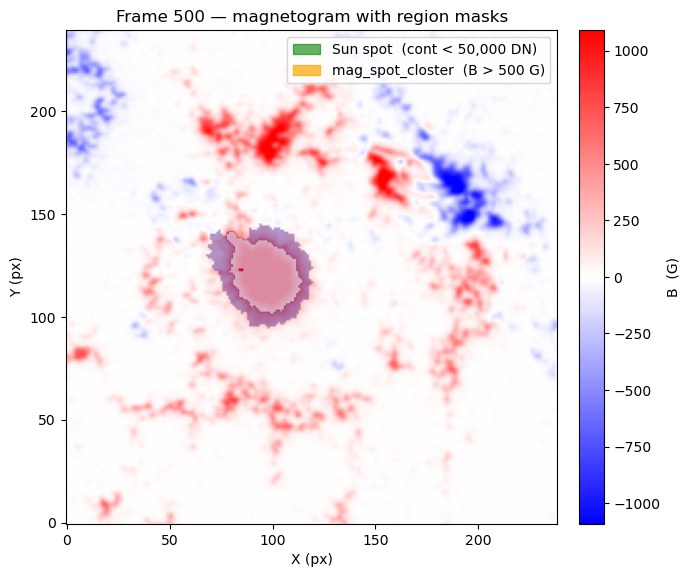

In [57]:
mag_spot_closter = (cube_mag > 500) & sun_spot

fig, ax = plt.subplots(figsize=(7, 7))

image_idx = 500

vmax = np.nanpercentile(np.abs(cube_mag[image_idx][np.isfinite(cube_mag[image_idx])]), 99)
im = ax.imshow(cube_mag[image_idx], cmap='bwr', origin='lower', vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)

ax.imshow(np.where(sun_spot[image_idx],         1.0, np.nan), cmap='Purples',  alpha=0.4, origin='lower', vmin=0, vmax=1)
ax.imshow(np.where(mag_spot_closter[image_idx], 1.0, np.nan), cmap='gray', alpha=0.55, origin='lower', vmin=0, vmax=1)

ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title(f'Frame {image_idx} — magnetogram with region masks')
ax.legend(handles=[
    mpatches.Patch(color='green',  alpha=0.6, label=f'Sun spot  (cont < {CONT_THRESH_PEM:,} DN)'),
    mpatches.Patch(color='orange', alpha=0.7, label='mag_spot_closter  (B > 500 G)'),
], loc='upper right')
plt.tight_layout()
plt.show()

### compute metrics

In [58]:
from scipy.ndimage import center_of_mass
cms = np.array([center_of_mass(umbra[i]) for i in range(penumbra.shape[0])])

In [59]:
# mean over penumbra region per frame


mean_mag_umb = np.array([np.nanmean(cube_mag[t][umbra[t]]) if umbra[t].any() else np.nan for t in range(n_t)])
mean_mag_pen = np.array([np.nanmean(cube_mag[t][penumbra[t]]) if penumbra[t].any() else np.nan for t in range(n_t)])
mean_mag_both = np.array([np.nanmean(cube_mag[t][mag_spot_closter[t]]) if both[t].any() else np.nan for t in range(n_t)])
mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(cube_mag_qsun.shape[0])])

mean_dop_pen = np.array([np.nanmean(cube_dop[t][penumbra[t]]) if penumbra[t].any() else np.nan for t in range(n_t)])
mean_dop_umb = np.array([np.nanmean(cube_dop[t][umbra[t]]) if umbra[t].any() else np.nan for t in range(n_t)])
mean_dop_both = np.array([np.nanmean(cube_dop[t][both[t]]) if both[t].any() else np.nan for t in range(n_t)])
mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(cube_dop_qsun.shape[0])])

n_pix = umbra.sum(axis=(1, 2))
print(f'Penumbra pixels / frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}')
print(f'Mean B over penumbra  : {np.nanmean(mean_mag_umb):.1f} G')
print(f'Mean B over umbra  : {np.nanmean(mean_mag_pen):.1f} G')
print(f'Mean v over penumbra  : {np.nanmean(mean_dop_pen):.1f} m/s')
print(f'Mean v over umbra  : {np.nanmean(mean_dop_umb):.1f} m/s')

Penumbra pixels / frame  →  mean=286, min=108, max=370
Mean B over penumbra  : 1200.5 G
Mean B over umbra  : 452.7 G
Mean v over penumbra  : -299.1 m/s
Mean v over umbra  : -212.5 m/s


In [47]:
area_pen = penumbra.sum(axis=(1, 2))
area_umb = umbra.sum(axis=(1, 2))
area_both = both.sum(axis=(1, 2))



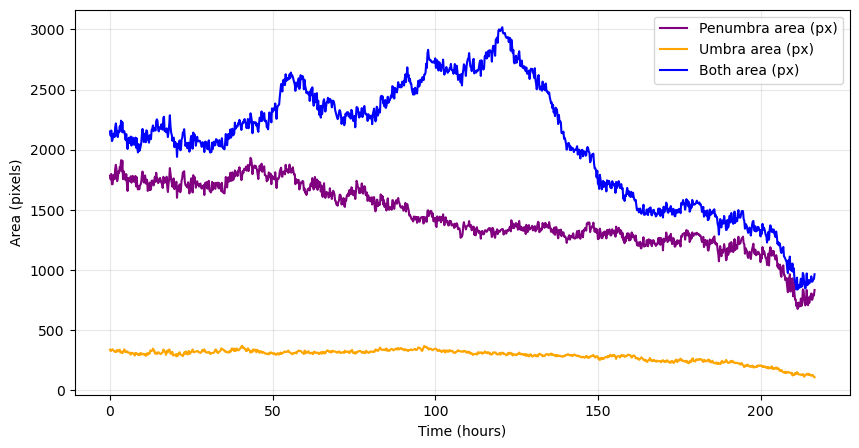

In [60]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(time_h, area_pen, label='Penumbra area (px)', color='purple')
ax1.plot(time_h, area_umb, label='Umbra area (px)', color='orange')
ax1.plot(time_h, area_both, label='Both area (px)', color='blue')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Area (pixels)')
ax1.grid(alpha=0.3)
ax1.legend()
plt.show()

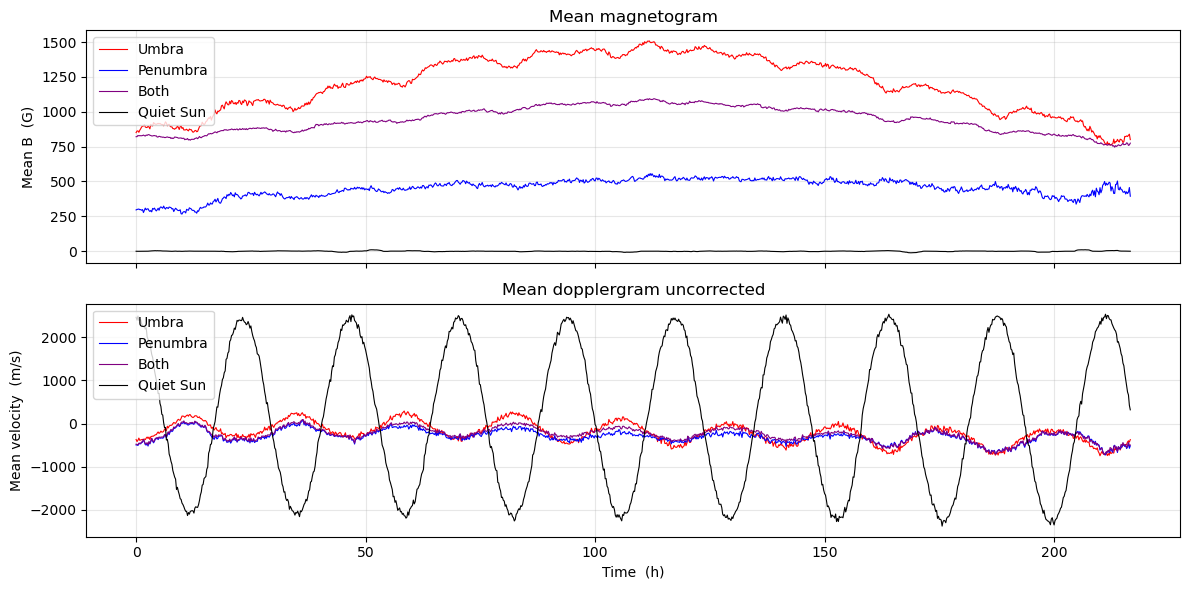

In [61]:
# ── time-series: mean magnetogram & dopplergram over the penumbra ────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time_h, mean_mag_umb, color='red', lw=0.8, label='Umbra')
ax1.plot(time_h, mean_mag_pen, color='blue', lw=0.8, label='Penumbra')
ax1.plot(time_h, mean_mag_both, color='purple', lw=0.8, label='Both')
ax1.plot(time_h, mean_mag_quiet, color='black', lw=0.8, label='Quiet Sun')
ax1.set_ylabel('Mean B  (G)')
ax1.set_title('Mean magnetogram')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(time_h, mean_dop_umb, color='red', lw=0.8, label='Umbra')
ax2.plot(time_h, mean_dop_pen, color='blue', lw=0.8,label='Penumbra')
ax2.plot(time_h, mean_dop_both, color='purple', lw=0.8, label='Both')
ax2.plot(time_h, mean_dop_quiet, color='black', lw=0.8, label='Quiet Sun')
ax2.set_ylabel('Mean velocity  (m/s)')
ax2.set_xlabel('Time  (h)')
ax2.set_title('Mean dopplergram uncorrected')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


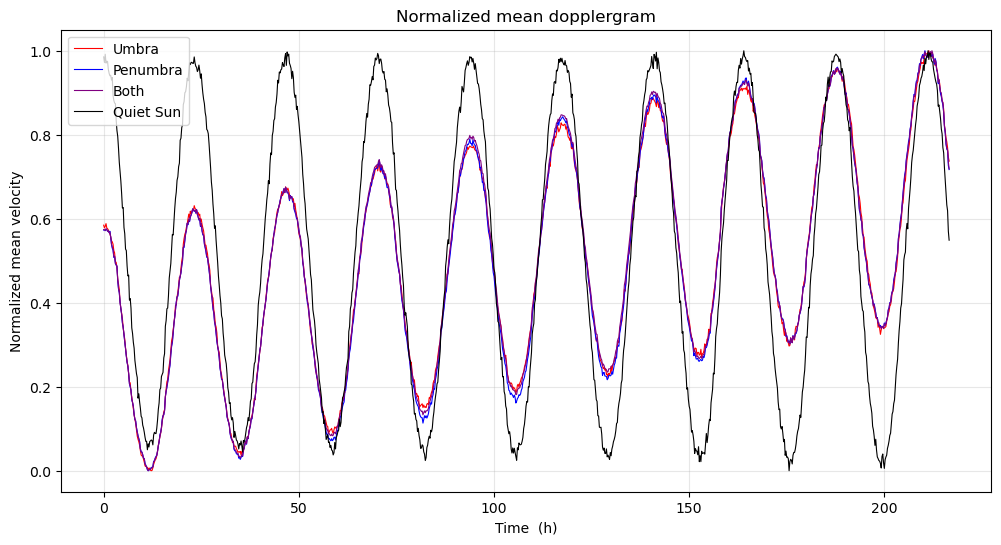

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

def normalize(arr):
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

ax.plot(time_h, normalize(mean_dop_umb), color='red', lw=0.8, label='Umbra')
ax.plot(time_h, normalize(mean_dop_pen), color='blue', lw=0.8, label='Penumbra')
ax.plot(time_h, normalize(mean_dop_both), color='purple', lw=0.8, label='Both')
ax.plot(time_h, normalize(mean_dop_quiet), color='black', lw=0.8, label='Quiet Sun')
ax.set_ylabel('Normalized mean velocity')
ax.set_xlabel('Time  (h)')
ax.set_title('Normalized mean dopplergram')
ax.grid(alpha=0.3)
ax.legend()

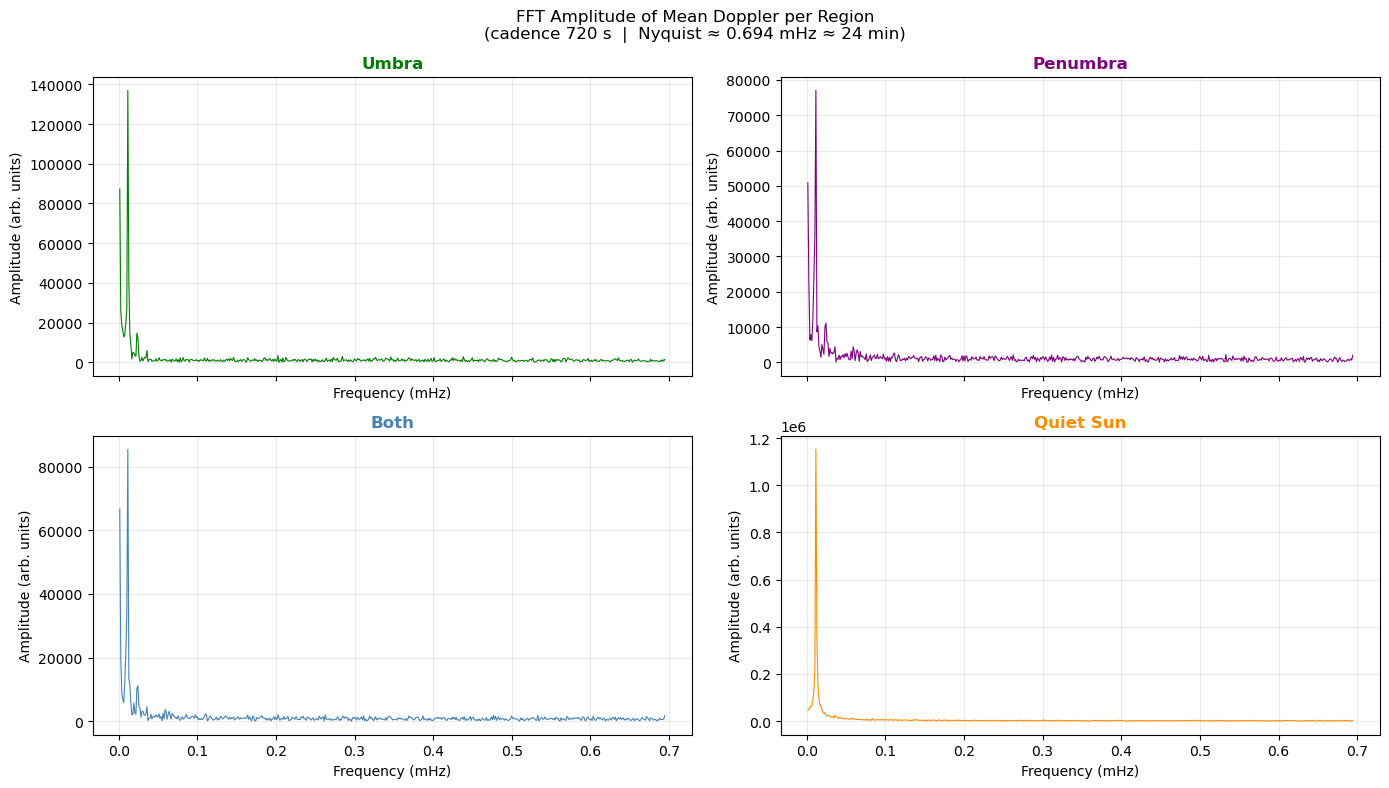

Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1445
Penumbra         3       0.0051         3252.0          0.1021
Penumbra         4       0.0359          464.6          0.0578
Penumbra         5       0.0589          282.8          0.0574

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8         

In [33]:
from scipy.signal import find_peaks

dt        = CADENCE_S                          # 720 s
freqs_hz  = np.fft.rfftfreq(n_t, d=dt)        # Hz  (length n_t//2 + 1)
f_hz      = freqs_hz[1:]                       # skip DC
f_mhz     = f_hz * 1e3                         # mHz

def compute_fft(ts):
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    return np.abs(np.fft.rfft(ts_c))

ffts = {
    'Umbra'    : (compute_fft(mean_dop_umb)[1:],   'green'),
    'Penumbra' : (compute_fft(mean_dop_pen)[1:],   'purple'),
    'Both'     : (compute_fft(mean_dop_both)[1:],  'steelblue'),
    'Quiet Sun': (compute_fft(mean_dop_quiet)[1:], 'darkorange'),
}

# ── FFT amplitude plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, (name, (amp, color)) in zip(axes.flat, ffts.items()):
    ax.plot(f_mhz, amp, color=color, lw=0.8)

    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    for idx in sorted(top5):
        period_min = 1000 / (f_mhz[idx] * 60)   # minutes
        #ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
        #ax.text(f_mhz[idx], amp[idx] * 1.05,
        #        f'{period_min:.0f} min', fontsize=7, color=color,
        #        rotation=90, va='bottom', ha='center')

    ax.set_title(name, color=color, fontweight='bold')
    ax.set_ylabel('Amplitude (arb. units)')
    ax.set_xlabel('Frequency (mHz)')
    ax.grid(alpha=0.25, which='major')

fig.suptitle('FFT Amplitude of Mean Doppler per Region\n(cadence 720 s  |  Nyquist ≈ {:.3f} mHz ≈ {:.0f} min)'.format(
    f_mhz[-1], 1000 / (f_mhz[-1] * 60)), fontsize=12)
plt.tight_layout()
plt.show()

# ── principal peak table ──────────────────────────────────────────────────────
print(f'{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. amplitude":>14}')
print('─' * 60)
for name, (amp, _) in ffts.items():
    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    a_max = amp.max()
    for rank, idx in enumerate(top5, 1):
        print(f'{name:<12}  {rank:>4}  {f_mhz[idx]:>11.4f}  '
              f'{1000/(f_mhz[idx]*60):>13.1f}  {amp[idx]/a_max:>14.4f}')
    print()


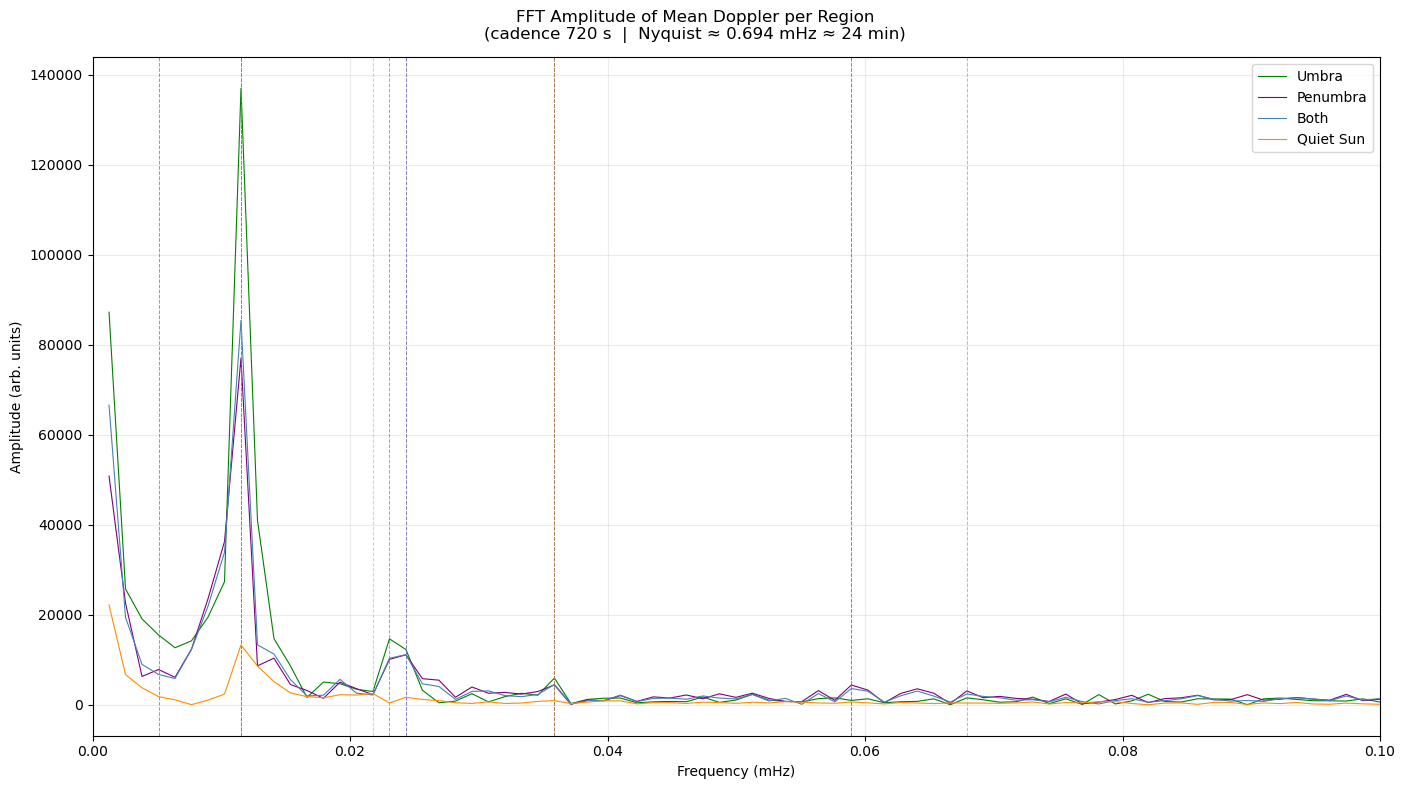

Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1445
Penumbra         3       0.0051         3252.0          0.1021
Penumbra         4       0.0359          464.6          0.0578
Penumbra         5       0.0589          282.8          0.0574

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8         

In [24]:
from scipy.signal import find_peaks

dt        = CADENCE_S                          # 720 s
freqs_hz  = np.fft.rfftfreq(n_t, d=dt)        # Hz  (length n_t//2 + 1)
f_hz      = freqs_hz[1:]                       # skip DC
f_mhz     = f_hz * 1e3                         # mHz

def compute_fft(ts):
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    return np.abs(np.fft.rfft(ts_c))

ffts = {
    'Umbra'    : (compute_fft(mean_dop_umb)[1:],   'green'),
    'Penumbra' : (compute_fft(mean_dop_pen)[1:],   'purple'),
    'Both'     : (compute_fft(mean_dop_both)[1:],  'steelblue'),
    'Quiet Sun': (compute_fft(mean_dop_quiet)[1:], 'darkorange'),
}

# ── FFT amplitude plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 8), sharex=True)

for (name, (amp, color)) in ffts.items():
    ax.plot(f_mhz, amp, color=color, lw=0.8,label=name)

    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    for idx in sorted(top5):
        period_min = 1000 / (f_mhz[idx] * 60)   # minutes
        ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
        #ax.text(f_mhz[idx], amp[idx] * 1.05,
        #        f'{period_min:.0f} min', fontsize=7, color=color,
        #        rotation=90, va='bottom', ha='center')

#ax.set_title('FFT Amplitude', color=color, fontweight='bold')
ax.set_ylabel('Amplitude (arb. units)')
ax.set_xlabel('Frequency (mHz)')
ax.grid(alpha=0.25, which='major')
ax.legend()

fig.suptitle('FFT Amplitude of Mean Doppler per Region\n(cadence 720 s  |  Nyquist ≈ {:.3f} mHz ≈ {:.0f} min)'.format(
    f_mhz[-1], 1000 / (f_mhz[-1] * 60)), fontsize=12)
plt.tight_layout()
plt.xlim(0,0.1)
plt.show()

# ── principal peak table ──────────────────────────────────────────────────────
print(f'{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. amplitude":>14}')
print('─' * 60)
for name, (amp, _) in ffts.items():
    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    a_max = amp.max()
    for rank, idx in enumerate(top5, 1):
        print(f'{name:<12}  {rank:>4}  {f_mhz[idx]:>11.4f}  '
              f'{1000/(f_mhz[idx]*60):>13.1f}  {amp[idx]/a_max:>14.4f}')
    print()




```
Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000 Q
Umbra            2       0.0051         3252.0          0.1330 U
Umbra            3       0.0231          722.7          0.1103 Q
Umbra            4       0.0359          464.6          0.0426 U
Umbra            5       0.2024           82.3          0.0237 Q

Penumbra         1       0.0115         1445.3          1.0000 Q
Penumbra         2       0.0243          684.6          0.1422 Q
Penumbra         3       0.0359          464.6          0.0553 U
Penumbra         4       0.0589          282.8          0.0536 Q
Penumbra         5       0.1102          151.3          0.0331 Q

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8          0.0425
Both             5       0.0679          245.4          0.0284

Quiet Sun        1       0.0115         1445.3          0.5992
Quiet Sun        2       0.0218          765.2          0.1129
Quiet Sun        3       0.0359          464.6          0.0431
Quiet Sun        4       0.6880           24.2          0.0402
Quiet Sun        5       0.2037           81.8          0.0358
```

In [25]:
save_path = pathlib.Path('../data/processed/sebastian_sun_spots/DS03/anim.html')

In [26]:
import matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as mpatches

matplotlib.rcParams['animation.embed_limit'] = 50   # MB

STEP = 50
frames_idx = np.arange(0, n_t, STEP)

cubes_ch  = [cube_cont,       cube_mag,         cube_dop]
cmaps_ch  = ['gray',          'bwr',             'RdBu_r']
labels_ch = ['Continuum (DN)','Magnetogram (G)', 'Dopplergram (m/s)']
clims     = [np.nanpercentile(c, [2, 98]) for c in cubes_ch]

def _make_rgba(umb, pen):
    """Green for umbra, purple for penumbra, transparent elsewhere."""
    h, w = umb.shape
    rgba = np.zeros((h, w, 4), dtype=float)
    rgba[pen, 0] = 0.55;  rgba[pen, 2] = 1.0;   rgba[pen, 3] = 0.40  # purple
    rgba[umb, 0] = 0.0;   rgba[umb, 1] = 0.85;  rgba[umb, 3] = 0.45  # green
    return rgba

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ims = []; overlays = []

for ax, cube, cmap, clim, lbl in zip(axes, cubes_ch, cmaps_ch, clims, labels_ch):
    im = ax.imshow(cube[0], origin='lower', cmap=cmap,
                   vmin=clim[0], vmax=clim[1], interpolation='nearest')
    fig.colorbar(im, ax=ax, label=lbl, fraction=0.046, pad=0.04)
    ov = ax.imshow(_make_rgba(umbra[0], penumbra[0]), origin='lower', interpolation='nearest')
    ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
    ax.text(0.02, 0.02, 'Cadence: 720 s', transform=ax.transAxes,
            color='white', fontsize=9, va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))
    ims.append(im); overlays.append(ov)

# legend (only needs to appear once — add to left panel)
axes[0].legend(handles=[
    mpatches.Patch(color=(0.0, 0.85, 0.0, 0.7), label='Umbra'),
    mpatches.Patch(color=(0.55, 0.0, 1.0, 0.7), label='Penumbra'),
], loc='upper right', fontsize=8)

suptitle = fig.suptitle('', y=1.01)

def _update_regions(i):
    t = frames_idx[i]
    rgba = _make_rgba(umbra[t], penumbra[t])
    for im, ov, cube in zip(ims, overlays, cubes_ch):
        im.set_data(cube[t])
        ov.set_data(rgba)
    elapsed_h = t * CADENCE_S / 3600
    b_u = f'{mean_mag_umb[t]:.0f}' if np.isfinite(mean_mag_umb[t]) else 'N/A'
    b_p = f'{mean_mag_pen[t]:.0f}' if np.isfinite(mean_mag_pen[t]) else 'N/A'
    suptitle.set_text(
        f'SDO/HMI  |  frame {t:04d}  |  t = {elapsed_h:.2f} h  |  '
        f'<B> umb={b_u} G   pen={b_p} G'
    )
    return ims + overlays

anim = FuncAnimation(fig, _update_regions, frames=len(frames_idx), interval=100, blit=False)
plt.close(fig)
#safe the animation as HTML
anim.save(save_path, writer='html', fps=5)
#uncoment to see the animation in the notebook (may be too large to embed)
#HTML(anim.to_jshtml())


2026-06-03 22:12:51 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


<file:///home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS03/anim.html>

# edicion y prueba de funciones

In [1]:
#%load_ext autoreload   
#%autoreload 2

import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.sunspot_analysis import (
    verify_cadence,
    load_and_mask,
    plot_calibration_frame,
    plot_histogram,
    plot_magnetogram_masks,
    plot_area,
    compute_metrics,
    save_metrics_csv,
    plot_time_series,
    plot_ffts_separate,
    plot_ffts_combined,
    save_animation,
)

# DS01

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────────
DS01_NAME      = 'DS01'
raw_dir_01      = pathlib.Path('../data/raw/sebastian_sun_spots') / DS01_NAME
processed_dir_01 = pathlib.Path('../data/processed/sebastian_sun_spots') / DS01_NAME
plots_dir_01    = processed_dir_01 / 'plots'

print('Raw data dir :', raw_dir_01)
print('Processed dir:', processed_dir_01)

Raw data dir : ../data/raw/sebastian_sun_spots/DS01
Processed dir: ../data/processed/sebastian_sun_spots/DS01


## Step 0 — Verify cadence from the `.sav` timing file

In [3]:
from scipy.io import readsav


sav_data = readsav(raw_dir_01 / 'cube_continuum_coords2times.sav')
sav_data.keys()



dict_keys(['hdrs', 'times', 'xd', 'yd'])

In [5]:
sav_data['hdrs']

rec.array([(1, -64, 2, 4096, 4096, b'2017-08-12T04:48:15', b'2017-08-12T04:48:15.000', b'2017-08-12T04:48:15.000', b'0x0000000000022112', b'$Id: polcal.c,v 1.8 2016', b'$Id: interpol_code.c,v 1.5 2016', b'$Id: interpol_code.c,v 1.5 2016', b'$Id: HMI_observables.c,v 1.55 2017', 1, 4, 6, '', '', 10, b'72', 33.1761, 22.0209, b'hmi.lookup_corrected_expanded[121048472][][3][38][49][0][79][6]', 121048472, 0, 11, 1022, 1, 45., b'2017.08.12_04:48:45_TAI', b'2017.08.12_04:48:52_TAI', 946.85 ,  236.3  , 31327.8, 1574.79, 2193, 6.50525,  56.5723, 6.96e+08, 1.49598e+11, 1.51619e+11, b'Helioprojective-cartesian', b'nan', b'nan', b'nan', b'nan', 0., b'arcsec', b'arcsec', 0.50400001, 0.50400001, 0., 0., 2048.5, 2048.5, b'HPLT-TAN', b'HPLN-TAN', b'             NaN', b'             NaN', b'             NaN', b'             NaN', 47638.9609375 , 64840.48046875, 173., 2.43152, -1.7709 , 15301.2, 42831.5, 47622.9, 65579.7, 172.112 ,  9682, 0, 12160148, 12160148, b'hmi.lev1[:#216585302,#216585278,#21658525

In [5]:
cadence_s, cadence_list = verify_cadence(raw_dir_01)
arr, counts = np.unique(cadence_list, return_counts=True)
dict(zip(arr, counts))

(median 720.0 s, max dev 2160.00 s)


/mnt/ubuntu/home/thomas/Desktop/sun_spots_pulsation_review/src/sunspot_analysis.py:139: UserWarning: Cadence check failed: 21 gaps deviate from 720.0 s (max deviation 2160.0 s)
  warnings.warn(


{np.float64(720.0): np.int64(1045),
 np.float64(1440.0): np.int64(20),
 np.float64(2880.0): np.int64(1)}

## Step 1 — Load cubes and build region masks

Adjust `umbra_thresh` and `penumbra_thresh` after looking at the calibration frame below.
Run **Steps 1–2** together until the masks look right, then proceed.

In [6]:
mag_filter_01 = lambda x : x>500

data = load_and_mask(
    ds_dir          = raw_dir_01,
    umbra_thresh    = 30_000,   # continuum DN — pixels below this → umbra
    penumbra_thresh = 50_000,   # continuum DN — upper bound for penumbra,
    mag_filter=mag_filter_01,
    cadence_s       = cadence_list,
)

print(f"Cube shape (n_t, ny, nx): {data['cube_cont'].shape}")
print(f"Time span: {data['time_h'][-1]:.1f} h  ({data['n_t']} frames @ {data['cadence_s']:.0f} s)")

Cube shape (n_t, ny, nx): (1067, 239, 239)
Time span: 217.8 h  (1067 frames @ 720 s)


## Step 2 — Calibration frame

Change `frame_idx` to inspect any frame.  
Green overlay = umbra, purple = penumbra.

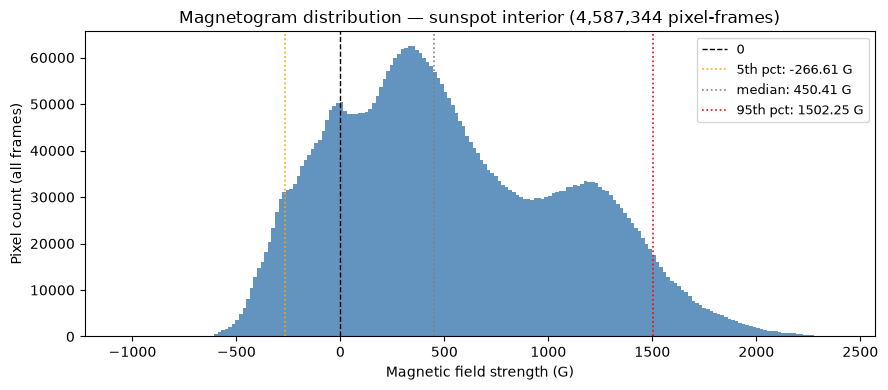

min=-1057.13  p1=-414.82  p5=-266.61  p25=104.07  median=450.41  p75=957.08  p95=1502.25  p99=1828.88  max=2396.79 G


In [7]:
# ── 2b: value histogram — inspect cube distribution ─────────────────────────
# Plots the full-cube histogram (all pixels × all frames).
# Change cube= to 'continuum' or 'dopplergram' to inspect those cubes.
# Use the printed percentile table to choose a mag_filter threshold.
plot_histogram(
    data,
    cube      = 'magnetogram',
    save      = False,
    plots_dir = plots_dir_01,
)


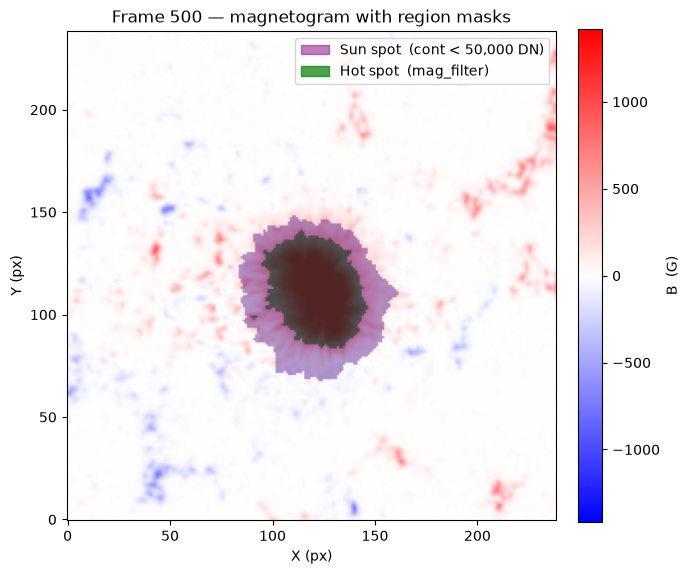

In [8]:
# ── 2c: magnetogram with region overlays ─────────────────────────────────────
# Purple = continuum-based sun_spot (umbra + penumbra).
# Orange = hot_spot (mag_filter region). Only shown if load_and_mask was called
# with a mag_filter; otherwise only the purple sun_spot overlay appears.
plot_magnetogram_masks(
    data,
    frame_idx = 500,    # None → middle frame
    save      = False,
    plots_dir = plots_dir_01,
)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/calibration_frame_0000.png


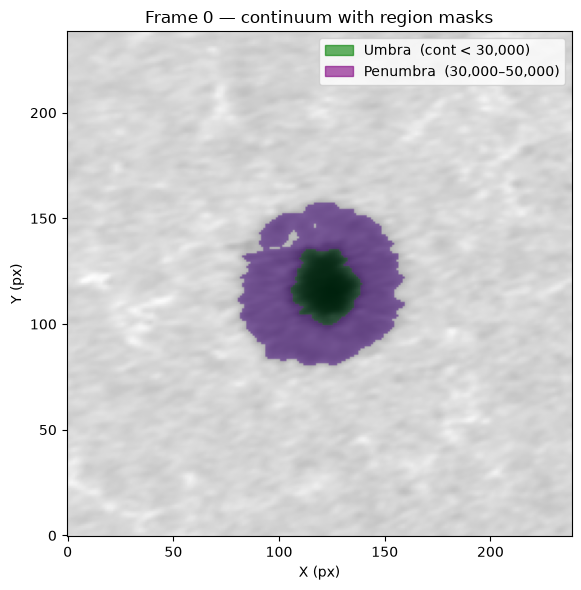

In [9]:
plot_calibration_frame(
    data,
    frame_idx = 0,       # use None for the middle frame, or any integer
    save      = True,
    plots_dir = plots_dir_01,
)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/calibration_frame_0500.png


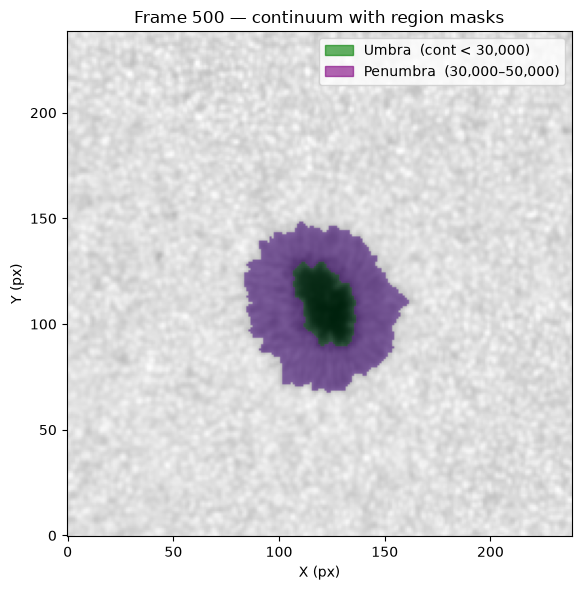

In [10]:
# Intermediate frame check — useful when the sunspot evolves significantly
plot_calibration_frame(
    data,
    frame_idx = 500,
    save      = True,
    plots_dir = plots_dir_01,
)

## Step 3 — Compute per-frame metrics

In [11]:
metrics = compute_metrics(data)

n_pix = data['umbra'].sum(axis=(1, 2))
print(f"Umbra pixels/frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}")
print(f"Mean B   umbra    : {np.nanmean(metrics['mean_mag_umb']):.1f} G")
print(f"Mean B   penumbra : {np.nanmean(metrics['mean_mag_pen']):.1f} G")
print(f"Mean v   umbra    : {np.nanmean(metrics['mean_dop_umb']):.1f} m/s")
print(f"Mean v   penumbra : {np.nanmean(metrics['mean_dop_pen']):.1f} m/s")

Umbra pixels/frame  →  mean=813, min=570, max=925
Mean B   umbra    : 1273.9 G
Mean B   penumbra : 361.3 G
Mean v   umbra    : -26.0 m/s
Mean v   penumbra : -146.1 m/s


## Step 4 — Save metrics CSV

In [12]:
data.keys()

dict_keys(['cube_cont', 'cube_mag', 'cube_dop', 'cube_dop_qsun', 'cube_mag_qsun', 'umbra', 'penumbra', 'both', 'hot_spot', 'time_h', 'n_t', 'cadence_s', 'umbra_thresh', 'penumbra_thresh'])

In [13]:
metrics['time'] = data['time_h']

In [14]:
import pandas as pd

df = pd.DataFrame(metrics)

In [15]:
save_metrics_csv(data, metrics, processed_dir_01)

Metrics saved → ../data/processed/sebastian_sun_spots/DS01/metrics.csv  (1067 rows)


PosixPath('../data/processed/sebastian_sun_spots/DS01/metrics.csv')

## Step 5 — Time-series plots

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/area_vs_time.png


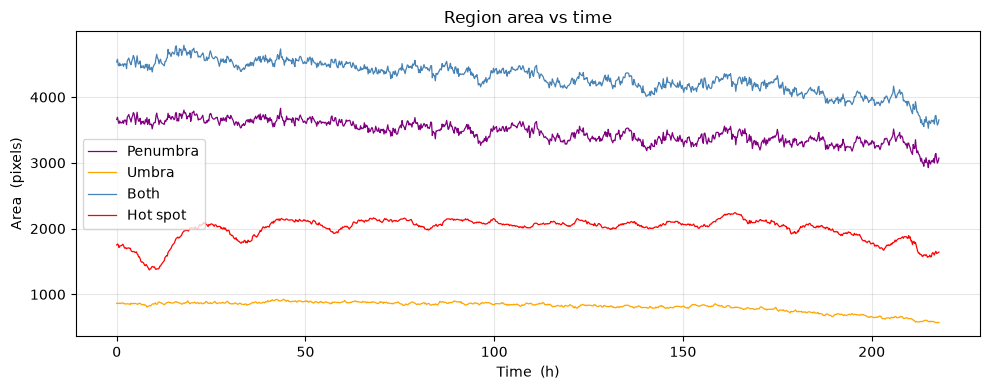

In [16]:
# ── area vs time ─────────────────────────────────────────────────────────────
# Pixel count of each region per frame. If hot_spot is defined it appears in red.
plot_area(data, metrics, save=True, plots_dir=plots_dir_01)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/time_series.png


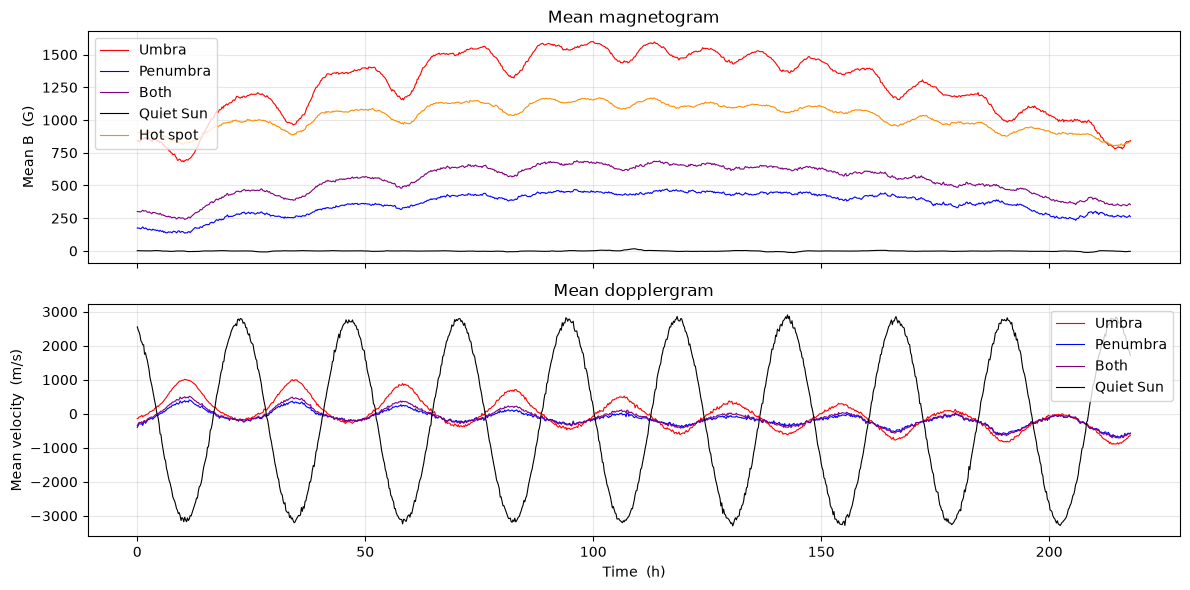

In [17]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir_01)

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/time_series_normalized.png


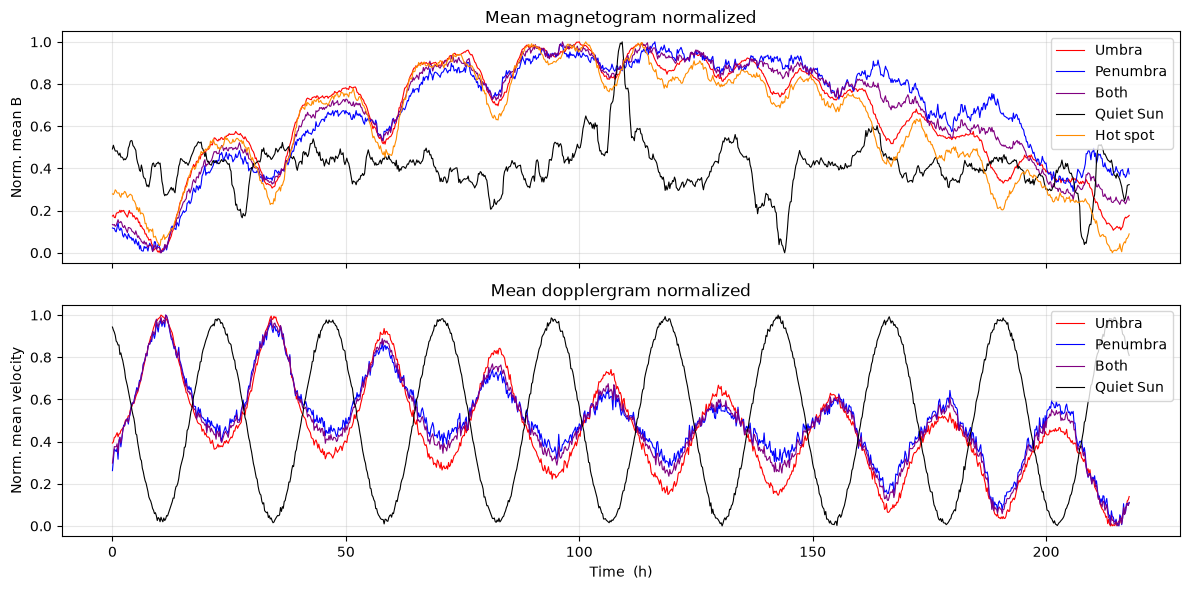

In [18]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_01)

## Step 6 — FFT analysis

### 6a — Separate subplots (one per region)

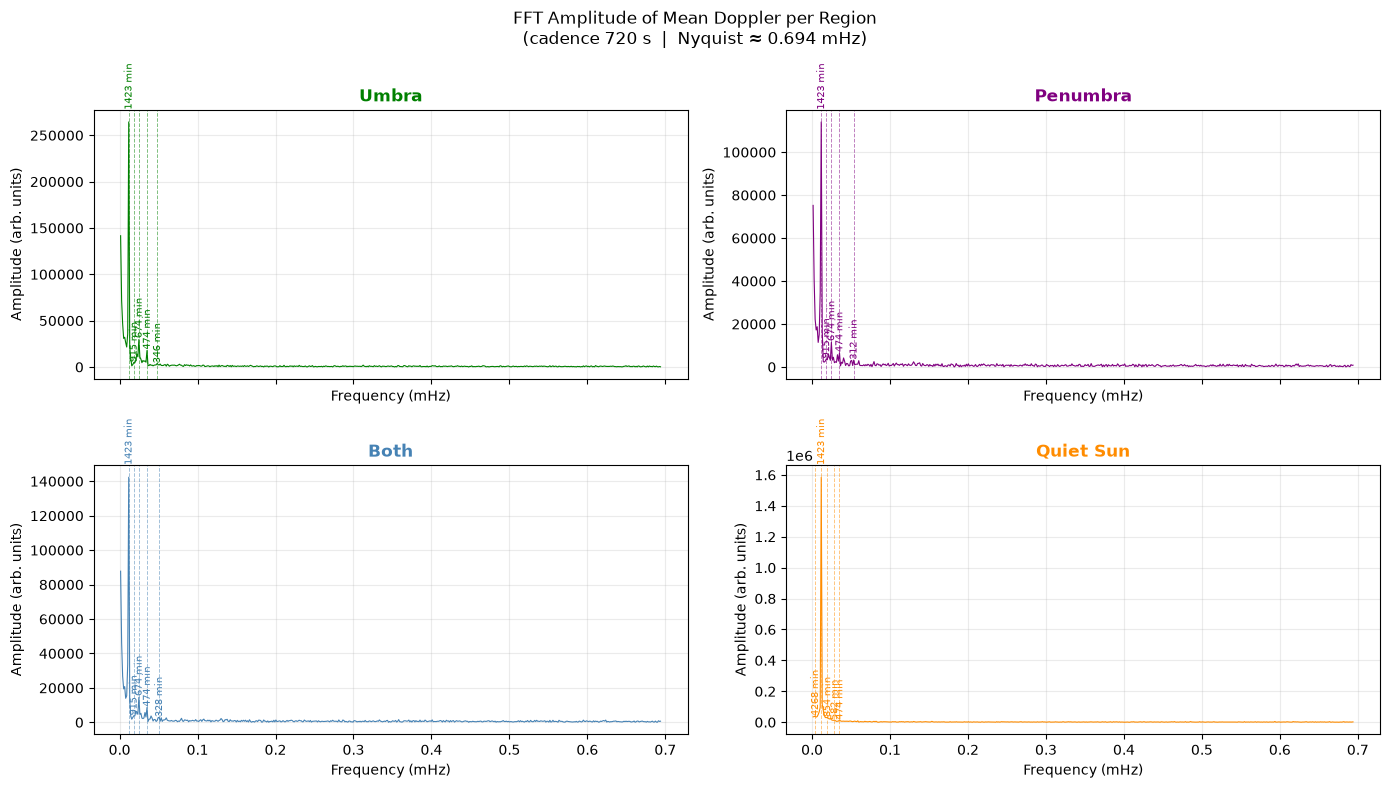


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1006
Penumbra         3       0.0351          474.2          0.0578
Penumbra         4       0.0182          914.6          0.0329
Penumbra         5       0.0534          312.3          0.0280

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

In [19]:
plot_ffts_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
    save           = False,
    plots_dir      = plots_dir_01,
)

### 6b — Combined plot with x-axis zoom

Adjust `xlim` to focus on the frequency range of interest (in mHz).  
The peak-table CSV (`fft_peaks.csv`) is saved alongside the figure.

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/fft_combined.png


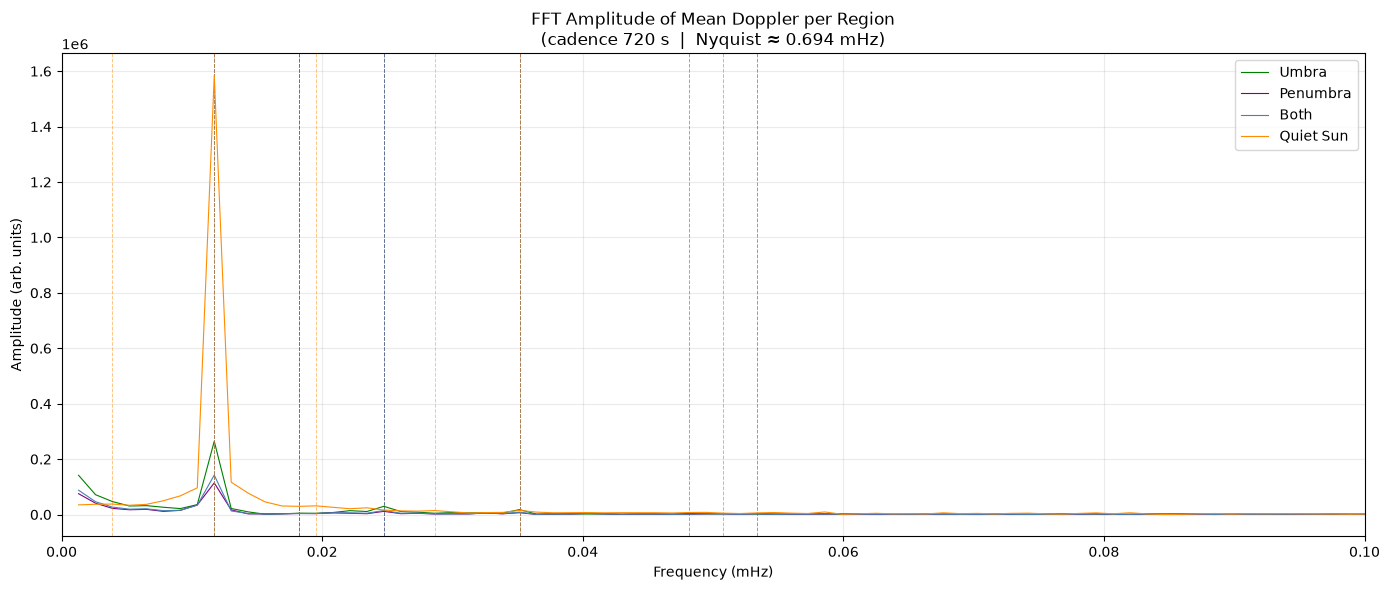


Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7          1.0000
Umbra            2       0.0247          673.9          0.1121
Umbra            3       0.0351          474.2          0.0674
Umbra            4       0.0182          914.6          0.0184
Umbra            5       0.0482          346.1          0.0141

Penumbra         1       0.0117         1422.7          1.0000
Penumbra         2       0.0247          673.9          0.1006
Penumbra         3       0.0351          474.2          0.0578
Penumbra         4       0.0182          914.6          0.0329
Penumbra         5       0.0534          312.3          0.0280

Both             1       0.0117         1422.7          1.0000
Both             2       0.0247          673.9          0.1021
Both             3       0.0351          474.2          0.0605
Both             4       0.0182          914.6        

In [20]:
plot_ffts_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
    save           = True,
    plots_dir      = plots_dir_01,
)

## Step 6c — Power spectral density (PSD) [prototype]

Same idea as Step 6, but computes a one-sided, density-normalized PSD
(`|FFT|² / (N·fs)`, units (m/s)²/Hz) via `scipy.signal.periodogram` instead of
raw FFT amplitude. Prototyping here before porting to `sunspot_analysis.py`.

In [21]:
# Mirrors _fft / _fft_regions / plot_ffts_separate / plot_ffts_combined in
# sunspot_analysis.py, but computes a one-sided PSD (density-normalized,
# units (m/s)^2/Hz) instead of raw FFT amplitude.

from scipy.signal import periodogram, find_peaks


def _psd(ts, cadence_s):
    """One-sided PSD (units^2/Hz) via FFT, skipping the DC bin. Returns (f_mhz, power)."""
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    fs = 1.0 / cadence_s
    freqs_hz, power = periodogram(ts_c, fs=fs, scaling='density', return_onesided=True)
    return freqs_hz[1:] * 1e3, power[1:]


def _psd_regions(metrics, cadence_s):
    """Return list of (name, f_mhz, power, color) for the four regions."""
    return [
        ('Umbra',     *_psd(metrics['mean_dop_umb'],   cadence_s), 'green'),
        ('Penumbra',  *_psd(metrics['mean_dop_pen'],   cadence_s), 'purple'),
        ('Both',      *_psd(metrics['mean_dop_both'],  cadence_s), 'steelblue'),
        ('Quiet Sun', *_psd(metrics['mean_dop_quiet'], cadence_s), 'darkorange'),
    ]


def _build_psd_peak_rows(regions):
    rows = []
    for name, f_mhz, power, _ in regions:
        peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
        top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
        p_max = power.max()
        for rank, idx in enumerate(top5, 1):
            rows.append({
                'region'    : name,
                'rank'      : rank,
                'freq_mhz'  : round(float(f_mhz[idx]), 4),
                'period_min': round(1000 / (f_mhz[idx] * 60), 1),
                'rel_power' : round(float(power[idx] / p_max), 4),
            })
    return rows


def _print_psd_peak_table(regions):
    print(f'\n{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. power":>10}')
    print('─' * 56)
    rows = _build_psd_peak_rows(regions)
    last_region = None
    for row in rows:
        if row['region'] != last_region and last_region is not None:
            print()
        last_region = row['region']
        print(f'{row["region"]:<12}  {row["rank"]:>4}  {row["freq_mhz"]:>11.4f}  '
              f'{row["period_min"]:>13.1f}  {row["rel_power"]:>10.4f}')
    print()


def plot_psd_separate(data, metrics, annotate_peaks=True, print_table=True):
    """2x2 subplot PSD for each region, mirrors plot_ffts_separate."""
    cadence_s = data['cadence_s']
    regions = _psd_regions(metrics, cadence_s)
    f_nyq = 1e3 / (2 * cadence_s)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, (name, f_mhz, power, color) in zip(axes.flat, regions):
        ax.plot(f_mhz, power, color=color, lw=0.8)
        ax.set_xlim(0,0.1)
        peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
        top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
        if annotate_peaks:
            for idx in sorted(top5):
                period_min = 1000 / (f_mhz[idx] * 60)
                ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
                ax.text(f_mhz[idx], power[idx] * 1.05,
                        f'{period_min:.0f} min', fontsize=7, color=color,
                        rotation=90, va='bottom', ha='center')
        ax.set_title(name, color=color, fontweight='bold')
        ax.set_ylabel('PSD  ((m/s)²/Hz)')
        ax.set_xlabel('Frequency (mHz)')
        ax.grid(alpha=0.25)

    fig.suptitle(
        f'Power Spectral Density of Mean Doppler per Region\n'
        f'(cadence {cadence_s:.0f} s  |  Nyquist ≈ {f_nyq:.3f} mHz)',
        fontsize=12)
    plt.tight_layout()
    plt.show()

    if print_table:
        _print_psd_peak_table(regions)


def plot_psd_combined(data, metrics, xlim=None, annotate_peaks=True, print_table=True):
    """Overlay PSD for all regions on a single axis, mirrors plot_ffts_combined."""
    cadence_s = data['cadence_s']
    regions = _psd_regions(metrics, cadence_s)
    f_nyq = 1e3 / (2 * cadence_s)

    fig, ax = plt.subplots(figsize=(14, 6))
    for name, f_mhz, power, color in regions:
        ax.plot(f_mhz, power, color=color, lw=0.8, label=name)
        
        if annotate_peaks:
            peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
            top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
            for idx in sorted(top5):
                ax.axvline(float(f_mhz[idx]), color=color, lw=0.7, ls='--', alpha=0.5)


    ax.set_ylabel('PSD  ((m/s)²/Hz)')
    ax.set_xlabel('Frequency (mHz)')
    ax.grid(alpha=0.25)
    ax.legend()
    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.set_title(
        f'Power Spectral Density of Mean Doppler per Region\n'
        f'(cadence {cadence_s:.0f} s  |  Nyquist ≈ {f_nyq:.3f} mHz)',
        fontsize=12)
    plt.tight_layout()
    plt.show()

    if print_table:
        _print_psd_peak_table(regions)

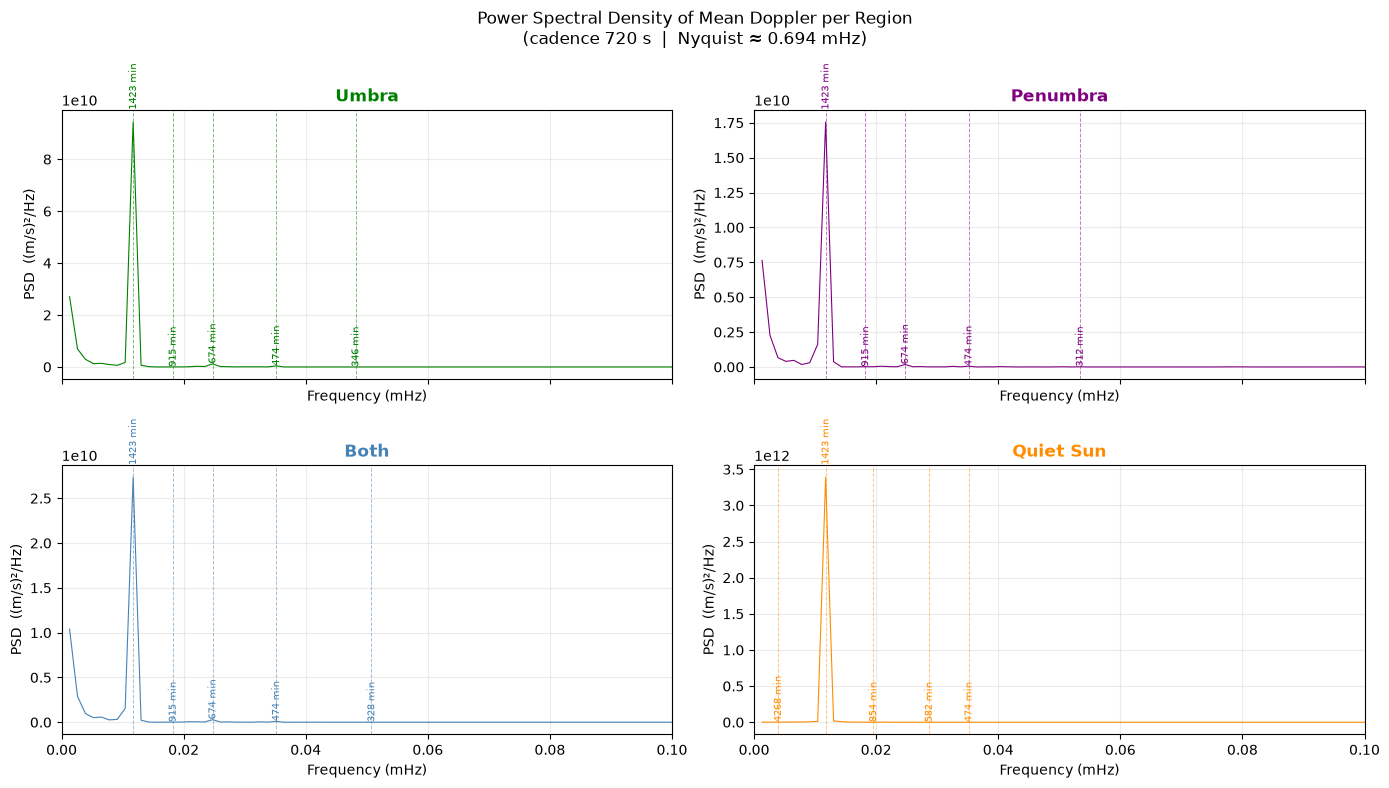


Region        Rank   Freq (mHz)   Period (min)  Rel. power
────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7      1.0000
Umbra            2       0.0247          673.9      0.0126
Umbra            3       0.0351          474.2      0.0045
Umbra            4       0.0182          914.6      0.0003
Umbra            5       0.0482          346.1      0.0002

Penumbra         1       0.0117         1422.7      1.0000
Penumbra         2       0.0247          673.9      0.0101
Penumbra         3       0.0351          474.2      0.0033
Penumbra         4       0.0182          914.6      0.0011
Penumbra         5       0.0534          312.3      0.0008

Both             1       0.0117         1422.7      1.0000
Both             2       0.0247          673.9      0.0104
Both             3       0.0351          474.2      0.0037
Both             4       0.0182          914.6      0.0007
Both             5       0.0508          328.3      0.0

In [22]:
plot_psd_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
)

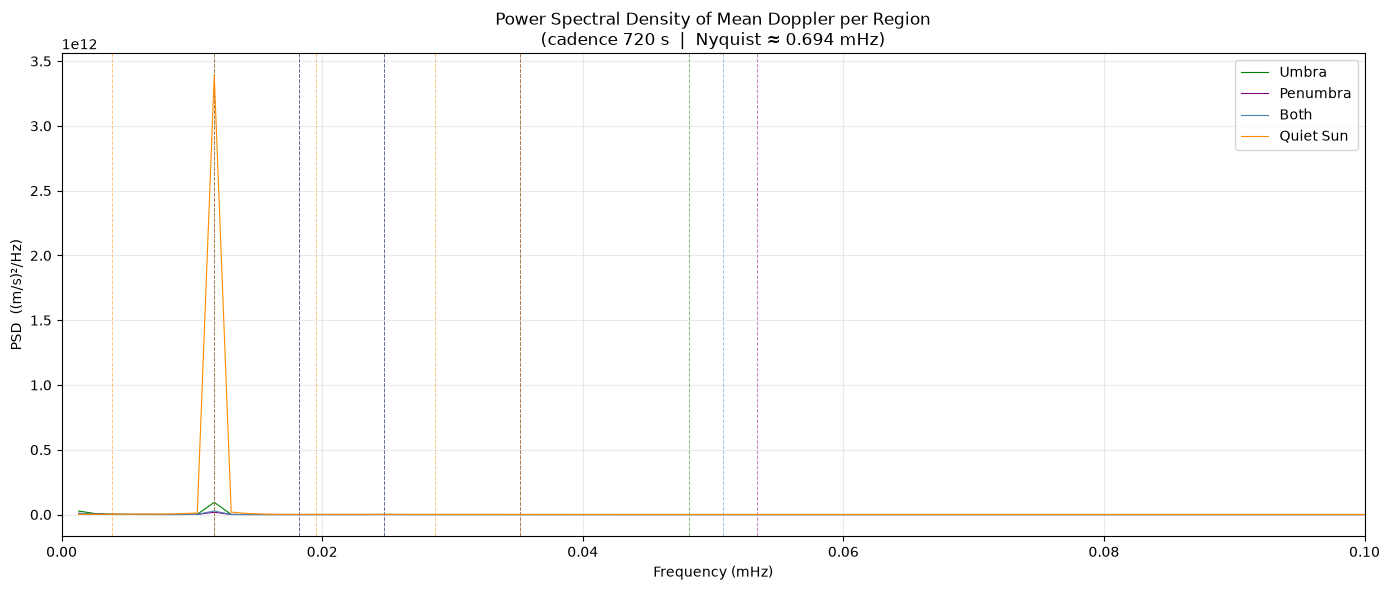


Region        Rank   Freq (mHz)   Period (min)  Rel. power
────────────────────────────────────────────────────────
Umbra            1       0.0117         1422.7      1.0000
Umbra            2       0.0247          673.9      0.0126
Umbra            3       0.0351          474.2      0.0045
Umbra            4       0.0182          914.6      0.0003
Umbra            5       0.0482          346.1      0.0002

Penumbra         1       0.0117         1422.7      1.0000
Penumbra         2       0.0247          673.9      0.0101
Penumbra         3       0.0351          474.2      0.0033
Penumbra         4       0.0182          914.6      0.0011
Penumbra         5       0.0534          312.3      0.0008

Both             1       0.0117         1422.7      1.0000
Both             2       0.0247          673.9      0.0104
Both             3       0.0351          474.2      0.0037
Both             4       0.0182          914.6      0.0007
Both             5       0.0508          328.3      0.0

In [23]:
plot_psd_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
)

## Step 7 — Save animation

In [24]:
anim_path = processed_dir_01 / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = 50,   # include every 50th frame
    fps       = 5,  
    mag_symmetric_cbar=True
)

Animation saved → ../data/processed/sebastian_sun_spots/DS01/anim.html


In [25]:
# Open the saved animation in the browser
from IPython.display import FileLink
FileLink(str(anim_path))


/mnt/ubuntu/home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS01/anim.html

## Step 8 — Parabola fit on magnetogram (excl. quiet sun)

fin for Umbra: Y = -0.06x²+13.92x+767.32
fin for Penumbra: Y = -0.02x²+5.31x+135.71
fin for Both: Y = -0.03x²+7.19x+253.46
fin for Hot spot: Y = -0.03x²+5.37x+842.63


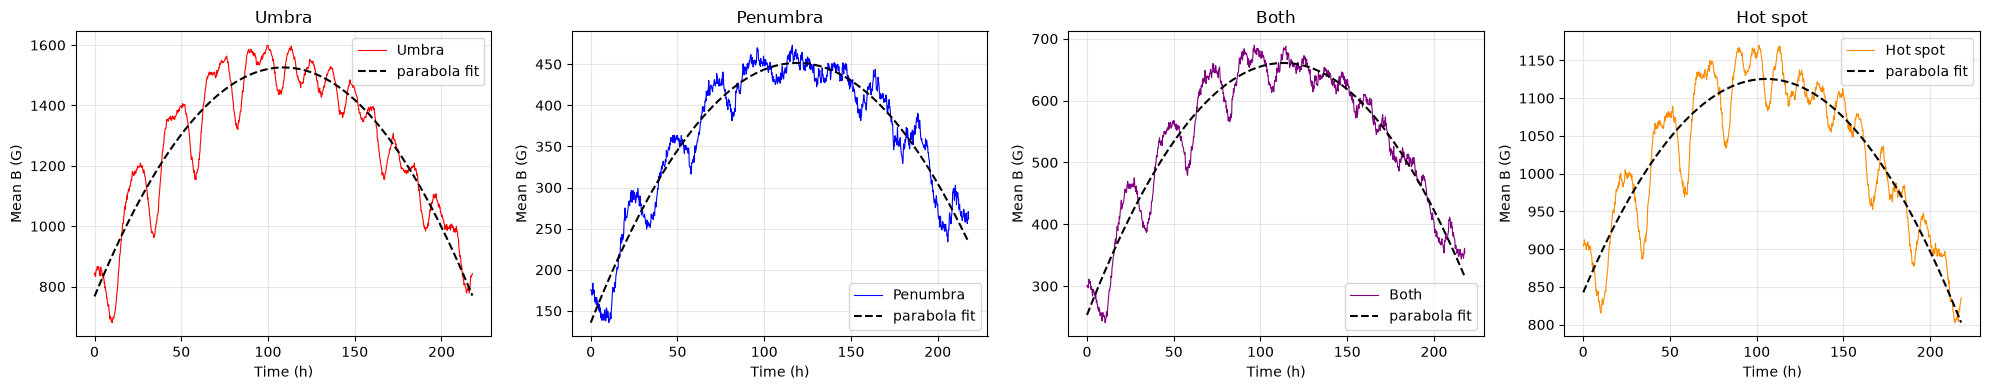

In [26]:
mag_regions = {
    'Umbra':    ('mean_mag_umb',  'red'),
    'Penumbra': ('mean_mag_pen',  'blue'),
    'Both':     ('mean_mag_both', 'purple'),
}
if 'mean_mag_hotspot' in metrics:
    mag_regions['Hot spot'] = ('mean_mag_hotspot', 'darkorange')

time_h = data['time_h']
parab_fits = {}

fig, axes = plt.subplots(1, len(mag_regions), figsize=(5 * len(mag_regions), 4), sharex=True)
for ax, (name, (key, color)) in zip(axes, mag_regions.items()):
    series = metrics[key]
    coeffs = np.polyfit(time_h, series, 2)
    print(
        f'fin for {name}: Y = {coeffs[0]:.2f}x²+{coeffs[1]:.2f}x+{coeffs[2]:.2f}'
    )
    fit = np.polyval(coeffs, time_h)
    parab_fits[name] = fit
    ax.plot(time_h, series, color=color, lw=0.8, label=name)
    ax.plot(time_h, fit, color='black', lw=1.5, ls='--', label='parabola fit')
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Mean B (G)')
    ax.set_title(name)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

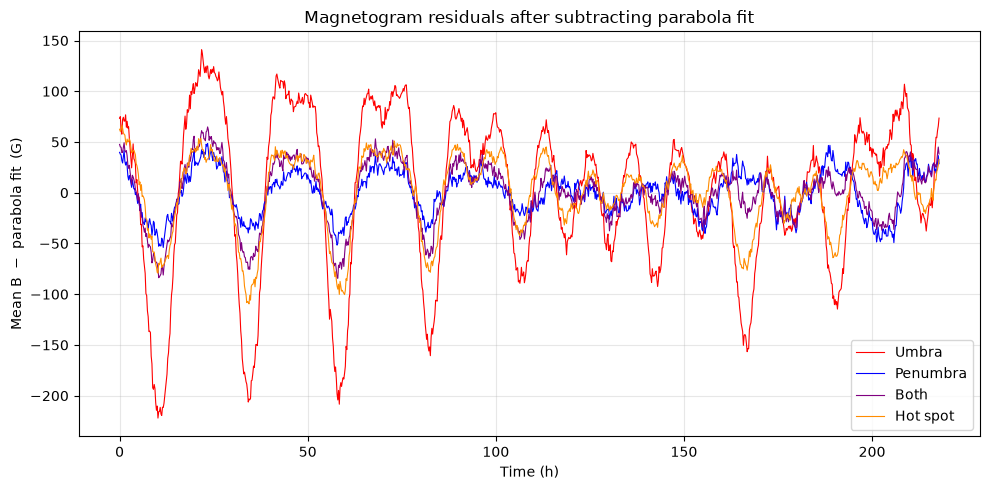

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, (key, color) in mag_regions.items():
    residual = metrics[key] - parab_fits[name]
    metrics[key+'_residual'] = residual
    ax.plot(time_h, residual, color=color, lw=0.8, label=name)
ax.set_xlabel('Time (h)')
ax.set_ylabel('Mean B  −  parabola fit  (G)')
ax.set_title('Magnetogram residuals after subtracting parabola fit')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
metrics.keys()

dict_keys(['mean_mag_umb', 'mean_mag_pen', 'mean_mag_both', 'mean_mag_quiet', 'mean_dop_umb', 'mean_dop_pen', 'mean_dop_both', 'mean_dop_quiet', 'area_umb', 'area_pen', 'area_both', 'mean_mag_hotspot', 'area_hotspot', 'time', 'mean_mag_umb_residual', 'mean_mag_pen_residual', 'mean_mag_both_residual', 'mean_mag_hotspot_residual'])

Figure saved → ../data/processed/sebastian_sun_spots/DS01/plots/time_series_normalized_residual.png


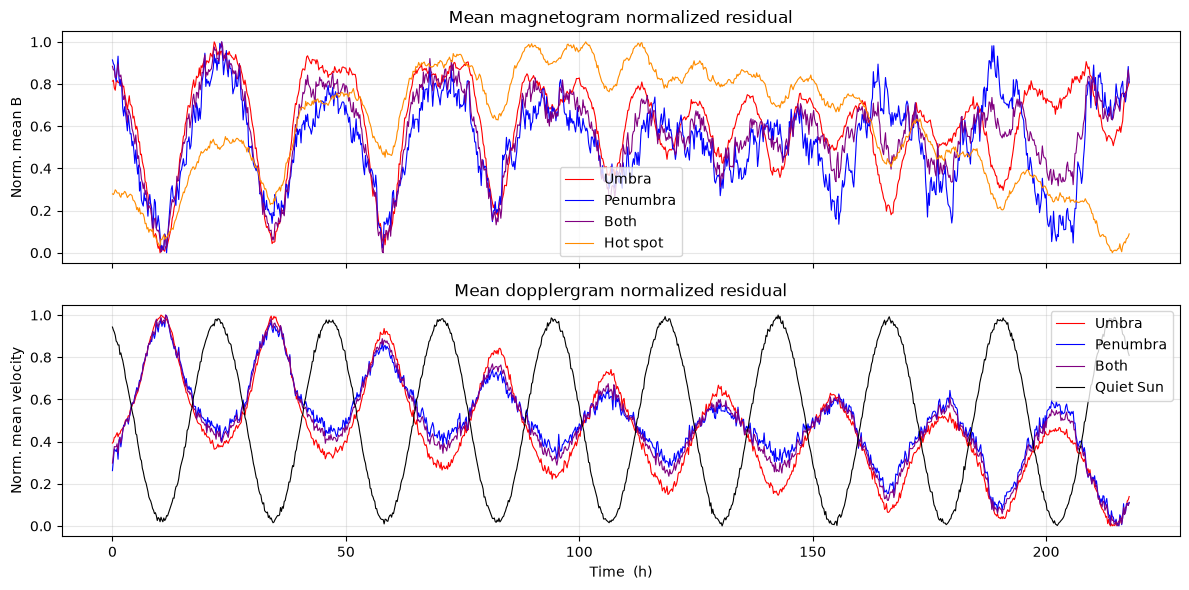

In [44]:
plot_time_series(data, metrics, normalized=True, save=True, plots_dir=plots_dir_01, mag_residual = True)

In [30]:

from scipy.signal import periodogram, find_peaks


def _psd(ts, cadence_s):
    """One-sided PSD (units^2/Hz) via FFT, skipping the DC bin. Returns (f_mhz, power)."""
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    fs = 1.0 / cadence_s
    freqs_hz, power = periodogram(ts_c, fs=fs, scaling='density', return_onesided=True)
    return freqs_hz[1:] * 1e3, power[1:]


def _psd_regions(metrics, cadence_s):
    """Return list of (name, f_mhz, power, color) for the four regions."""
    return [
        ('Umbra',     *_psd(metrics['mean_mag_umb_residual'],   cadence_s), 'green'),
        ('Penumbra',  *_psd(metrics['mean_mag_pen_residual'],   cadence_s), 'purple'),
        ('Both',      *_psd(metrics['mean_mag_both_residual'],  cadence_s), 'steelblue'),
        ('hot_spot', *_psd(metrics['mean_mag_hotspot_residual'], cadence_s), 'darkorange'),
    ]


def _build_psd_peak_rows(regions):
    rows = []
    for name, f_mhz, power, _ in regions:
        peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
        top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
        p_max = power.max()
        for rank, idx in enumerate(top5, 1):
            rows.append({
                'region'    : name,
                'rank'      : rank,
                'freq_mhz'  : round(float(f_mhz[idx]), 4),
                'period_min': round(1000 / (f_mhz[idx] * 60), 1),
                'rel_power' : round(float(power[idx] / p_max), 4),
            })
    return rows


def _print_psd_peak_table(regions):
    print(f'\n{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. power":>10}')
    print('─' * 56)
    rows = _build_psd_peak_rows(regions)
    last_region = None
    for row in rows:
        if row['region'] != last_region and last_region is not None:
            print()
        last_region = row['region']
        print(f'{row["region"]:<12}  {row["rank"]:>4}  {row["freq_mhz"]:>11.4f}  '
              f'{row["period_min"]:>13.1f}  {row["rel_power"]:>10.4f}')
    print()


def plot_psd_separate(data, metrics, annotate_peaks=True, print_table=True):
    """2x2 subplot PSD for each region, mirrors plot_ffts_separate."""
    cadence_s = data['cadence_s']
    regions = _psd_regions(metrics, cadence_s)
    f_nyq = 1e3 / (2 * cadence_s)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    for ax, (name, f_mhz, power, color) in zip(axes.flat, regions):
        ax.plot(f_mhz, power, color=color, lw=0.8)
        ax.set_xlim(0,0.1)
        peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
        top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
        if annotate_peaks:
            for idx in sorted(top5):
                period_min = 1000 / (f_mhz[idx] * 60)
                ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
                ax.text(f_mhz[idx], power[idx] * 1.05,
                        f'{period_min:.0f} min', fontsize=7, color=color,
                        rotation=90, va='bottom', ha='center')
        ax.set_title(name, color=color, fontweight='bold')
        ax.set_ylabel('PSD  ((m/s)²/Hz)')
        ax.set_xlabel('Frequency (mHz)')
        ax.grid(alpha=0.25)

    fig.suptitle(
        f'Power Spectral Density of Mean mag residual per Region\n'
        f'(cadence {cadence_s:.0f} s  |  Nyquist ≈ {f_nyq:.3f} mHz)',
        fontsize=12)
    plt.tight_layout()
    plt.show()

    if print_table:
        _print_psd_peak_table(regions)


def plot_psd_combined(data, metrics, xlim=None, annotate_peaks=True, print_table=True):
    """Overlay PSD for all regions on a single axis, mirrors plot_ffts_combined."""
    cadence_s = data['cadence_s']
    regions = _psd_regions(metrics, cadence_s)
    f_nyq = 1e3 / (2 * cadence_s)

    fig, ax = plt.subplots(figsize=(14, 6))
    for name, f_mhz, power, color in regions:
        ax.plot(f_mhz, power, color=color, lw=0.8, label=name)
        
        if annotate_peaks:
            peaks, _ = find_peaks(power, height=np.percentile(power, 85), distance=5)
            top5 = peaks[np.argsort(power[peaks])[::-1][:5]]
            for idx in sorted(top5):
                ax.axvline(float(f_mhz[idx]), color=color, lw=0.7, ls='--', alpha=0.5)


    ax.set_ylabel('PSD  ((m/s)²/Hz)')
    ax.set_xlabel('Frequency (mHz)')
    ax.grid(alpha=0.25)
    ax.legend()
    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.set_title(
        f'Power Spectral Density of Mean Doppler per Region\n'
        f'(cadence {cadence_s:.0f} s  |  Nyquist ≈ {f_nyq:.3f} mHz)',
        fontsize=12)
    plt.tight_layout()
    plt.show()

    if print_table:
        _print_psd_peak_table(regions)



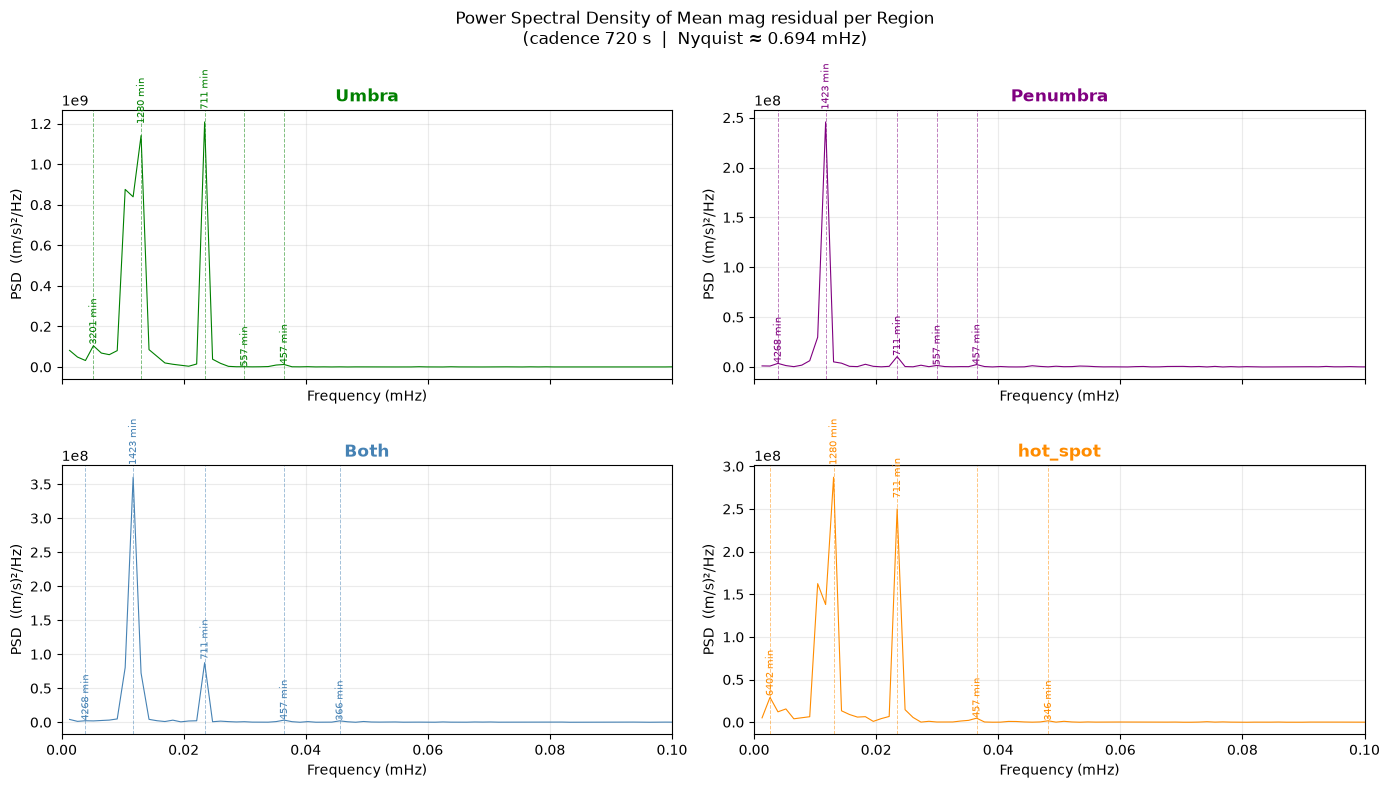


Region        Rank   Freq (mHz)   Period (min)  Rel. power
────────────────────────────────────────────────────────
Umbra            1       0.0234          711.3      1.0000
Umbra            2       0.0130         1280.4      0.9444
Umbra            3       0.0052         3201.0      0.0866
Umbra            4       0.0364          457.3      0.0101
Umbra            5       0.0299          556.7      0.0010

Penumbra         1       0.0117         1422.7      1.0000
Penumbra         2       0.0234          711.3      0.0423
Penumbra         3       0.0039         4268.0      0.0146
Penumbra         4       0.0364          457.3      0.0098
Penumbra         5       0.0299          556.7      0.0062

Both             1       0.0117         1422.7      1.0000
Both             2       0.0234          711.3      0.2431
Both             3       0.0364          457.3      0.0087
Both             4       0.0039         4268.0      0.0061
Both             5       0.0456          365.8      0.0

In [31]:
plot_psd_separate(
    data, metrics,
    annotate_peaks = True,
    print_table    = True,
)

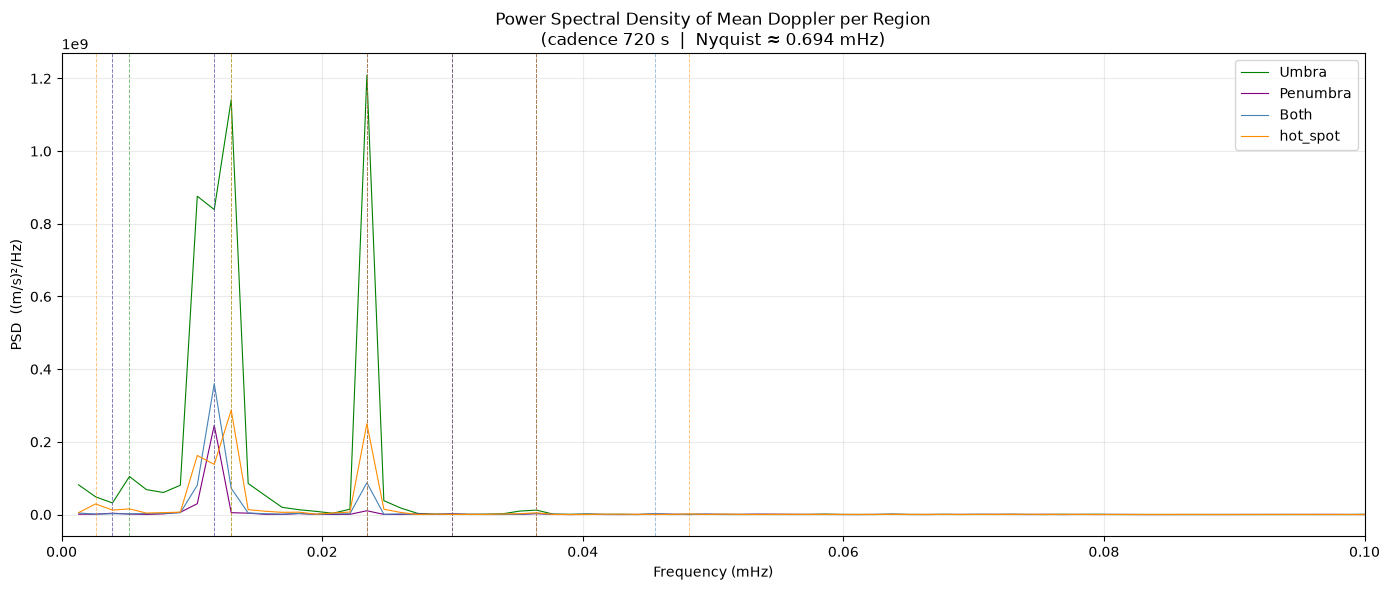


Region        Rank   Freq (mHz)   Period (min)  Rel. power
────────────────────────────────────────────────────────
Umbra            1       0.0234          711.3      1.0000
Umbra            2       0.0130         1280.4      0.9444
Umbra            3       0.0052         3201.0      0.0866
Umbra            4       0.0364          457.3      0.0101
Umbra            5       0.0299          556.7      0.0010

Penumbra         1       0.0117         1422.7      1.0000
Penumbra         2       0.0234          711.3      0.0423
Penumbra         3       0.0039         4268.0      0.0146
Penumbra         4       0.0364          457.3      0.0098
Penumbra         5       0.0299          556.7      0.0062

Both             1       0.0117         1422.7      1.0000
Both             2       0.0234          711.3      0.2431
Both             3       0.0364          457.3      0.0087
Both             4       0.0039         4268.0      0.0061
Both             5       0.0456          365.8      0.0

In [32]:
plot_psd_combined(
    data, metrics,
    xlim           = (0, 0.1),   # mHz — change or set to None for full range
    annotate_peaks = True,
    print_table    = True,
)

## Step 9 — Magnetogram residual vs Dopplergram power comparison

In [33]:
cadence_s = data['cadence_s']
region_keys = ['umb', 'pen', 'both']

f_mhz, _ = _psd(metrics['mean_dop_umb'], cadence_s)
metrics['psd_f_mhz'] = f_mhz

for r in region_keys:
    metrics[f'psd_dop_{r}'] = _psd(metrics[f'mean_dop_{r}'], cadence_s)[1]
    metrics[f'psd_mag_{r}_residual'] = _psd(metrics[f'mean_mag_{r}_residual'], cadence_s)[1]


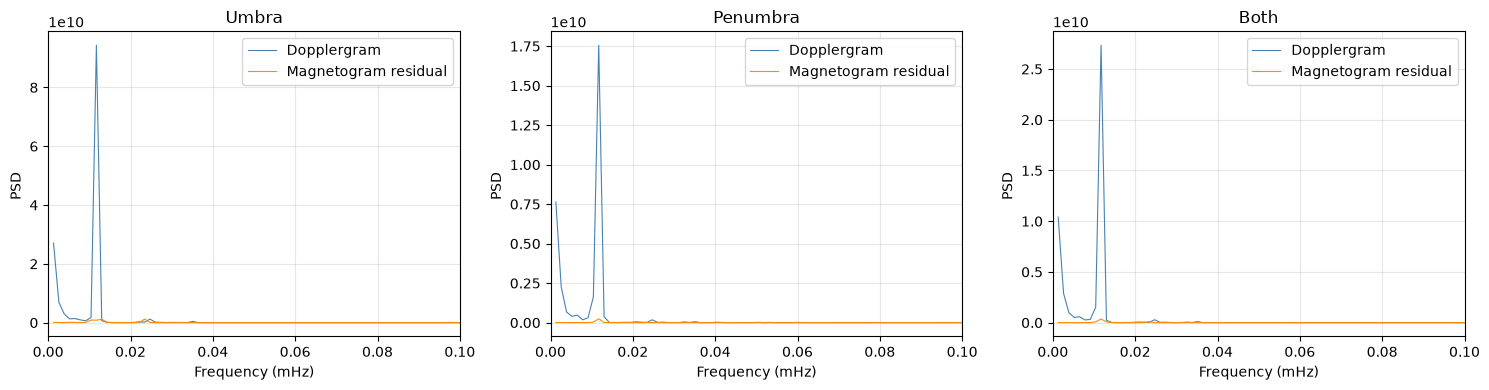

In [34]:
region_labels = {'umb': 'Umbra', 'pen': 'Penumbra', 'both': 'Both'}
f_mhz = metrics['psd_f_mhz']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, r in zip(axes, region_keys):
    ax.plot(f_mhz, metrics[f'psd_dop_{r}'], color='steelblue', lw=0.8, label='Dopplergram')
    ax.plot(f_mhz, metrics[f'psd_mag_{r}_residual'], color='darkorange', lw=0.8, label='Magnetogram residual')
    ax.set_xlim(0, 0.1)
    ax.set_title(region_labels[r])
    ax.set_xlabel('Frequency (mHz)')
    ax.set_ylabel('PSD ')
    ax.legend()
    ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


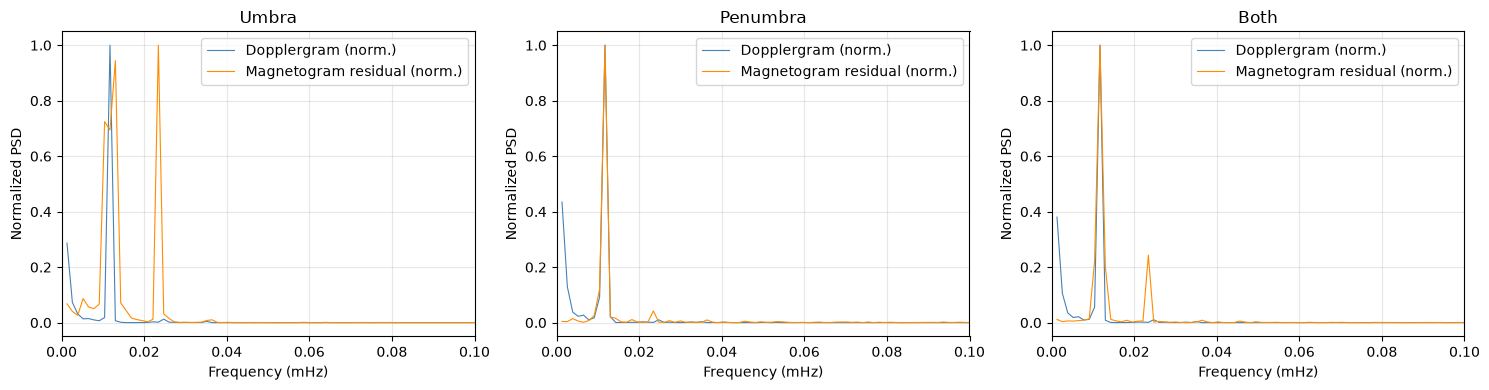

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, r in zip(axes, region_keys):
    psd_dop = metrics[f'psd_dop_{r}']
    psd_mag = metrics[f'psd_mag_{r}_residual']
    ax.plot(f_mhz, psd_dop / psd_dop.max(), color='steelblue', lw=0.8, label='Dopplergram (norm.)')
    ax.plot(f_mhz, psd_mag / psd_mag.max(), color='darkorange', lw=0.8, label='Magnetogram residual (norm.)')
    ax.set_xlim(0, 0.1)
    ax.set_title(region_labels[r])
    ax.set_xlabel('Frequency (mHz)')
    ax.set_ylabel('Normalized PSD')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


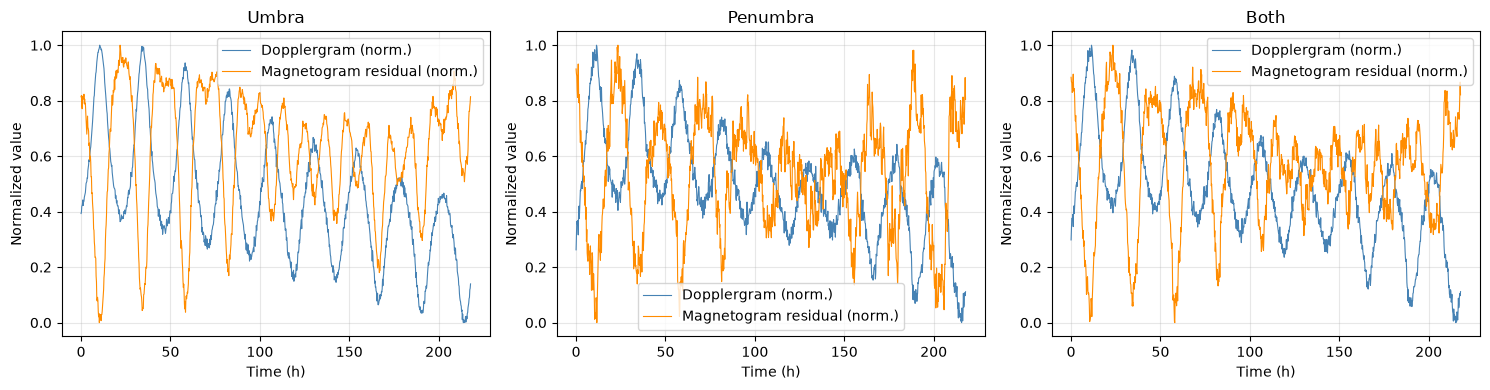

In [36]:
def normalize(arr):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, r in zip(axes, region_keys):
    ax.plot(time_h, normalize(metrics[f'mean_dop_{r}']), color='steelblue', lw=0.8, label='Dopplergram (norm.)')
    ax.plot(time_h, normalize(metrics[f'mean_mag_{r}_residual']), color='darkorange', lw=0.8, label='Magnetogram residual (norm.)')
    ax.set_title(region_labels[r])
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Normalized value')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 10 — Dopplergram moving average (removes the dominant ~1422 min oscillation)

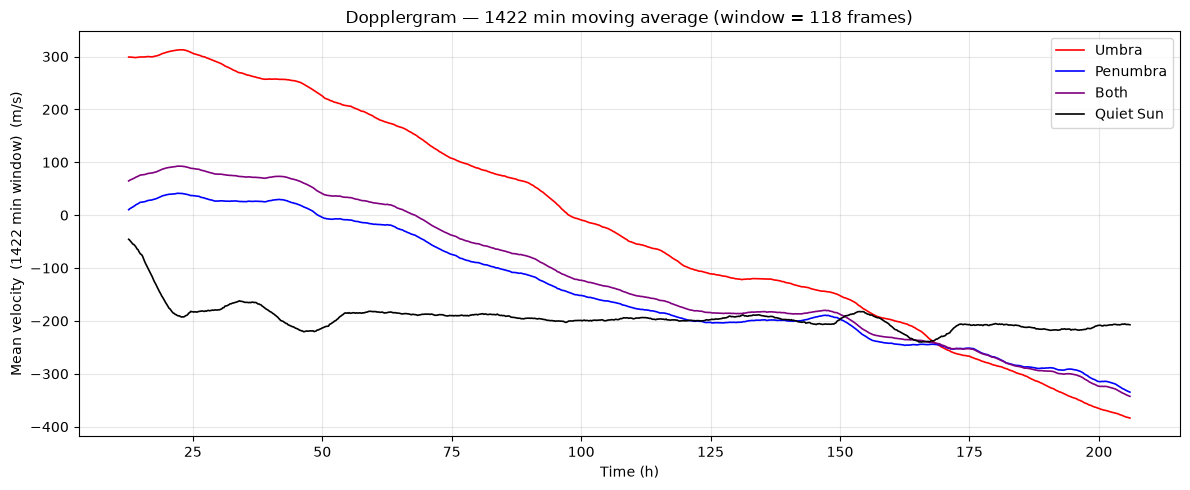

General average per region (after smoothing):
  Umbra     : -20.2 m/s
  Penumbra  : -139.4 m/s
  Both      : -115.5 m/s
  Quiet Sun : -194.5 m/s


In [37]:
def plot_dop_moving_average(data, metrics, window_min=1422):
    cadence_min = data['cadence_s'] / 60
    window = max(1, round(window_min / cadence_min))
    time_h = data['time_h']
    regions = {'umb': 'Umbra', 'pen': 'Penumbra', 'both': 'Both', 'quiet': 'Quiet Sun'}
    colors = {'umb': 'red', 'pen': 'blue', 'both': 'purple', 'quiet': 'black'}

    fig, ax = plt.subplots(figsize=(12, 5))
    overall_means = {}
    for r, label in regions.items():
        series = pd.Series(metrics[f'mean_dop_{r}'])
        smoothed = series.rolling(window, center=True).mean().to_numpy()
        overall_means[label] = np.nanmean(smoothed)
        ax.plot(time_h, smoothed, color=colors[r], lw=1.2, label=label)

    ax.set_xlabel('Time (h)')
    ax.set_ylabel(f'Mean velocity  ({window_min:.0f} min window)  (m/s)')
    ax.set_title(f'Dopplergram — {window_min:.0f} min moving average (window = {window} frames)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('General average per region (after smoothing):')
    for label, val in overall_means.items():
        print(f'  {label:<10}: {val:.1f} m/s')

    return overall_means


dop_overall_means = plot_dop_moving_average(data, metrics)


In [38]:
metrics.keys()

dict_keys(['mean_mag_umb', 'mean_mag_pen', 'mean_mag_both', 'mean_mag_quiet', 'mean_dop_umb', 'mean_dop_pen', 'mean_dop_both', 'mean_dop_quiet', 'area_umb', 'area_pen', 'area_both', 'mean_mag_hotspot', 'area_hotspot', 'time', 'mean_mag_umb_residual', 'mean_mag_pen_residual', 'mean_mag_both_residual', 'mean_mag_hotspot_residual', 'psd_f_mhz', 'psd_dop_umb', 'psd_mag_umb_residual', 'psd_dop_pen', 'psd_mag_pen_residual', 'psd_dop_both', 'psd_mag_both_residual'])

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import rfft, irfft, rfftfreq


def remove_period(signal, dt_min, period_min, width=0.0002):
    """
    Remove a specific period from a time series using FFT.

    Parameters
    ----------
    signal : array-like
        Time series.
    dt_min : float
        Sampling cadence in minutes.
    period_min : float
        Period to remove in minutes.
    width : float
        Frequency bandwidth around target frequency.
    """

    signal = np.asarray(signal)

    # Fill NaNs before FFT
    mask = np.isnan(signal)
    if np.any(mask):
        signal = pd.Series(signal).interpolate(
            limit_direction='both'
        ).to_numpy()


    freqs = rfftfreq(len(signal), d=dt_min)
    spectrum = rfft(signal)
    
    target_freq = 1.0 / period_min

    band = np.abs(freqs - target_freq) < width
    spectrum[band] = 0

    return irfft(spectrum, n=len(signal))


def plot_power_spectra_before_after(
    data,
    metrics,
    period_min=1442,
):

    cadence_min = data['cadence_s'] / 60

    regions = {
        'umb': 'Umbra',
        'pen': 'Penumbra',
        'both': 'Both',
        'quiet': 'Quiet Sun'
    }

    target_freq = 1.0 / period_min

    fig, axes = plt.subplots(
        len(regions),
        2,
        figsize=(14, 12),
        sharex=True
    )

    for row, (r, label) in enumerate(regions.items()):

        signal = np.asarray(metrics[f'mean_dop_{r}'])

        # FFT no acepta NaN
        signal = (
            pd.Series(signal)
            .interpolate(limit_direction='both')
            .to_numpy()
        )

        freqs = rfftfreq(len(signal), d=cadence_min)

        spectrum = rfft(signal)

        power_before = np.abs(spectrum)**2

        # localizar el bin más cercano al periodo deseado
        idx = np.argmin(np.abs(freqs - target_freq))

        filtered_spectrum = spectrum.copy()
        filtered_spectrum[idx] = 0

        power_after = np.abs(filtered_spectrum)**2

        # ANTES
        axes[row, 0].plot(freqs, power_before)
        axes[row, 0].axvline(
            target_freq,
            color='red',
            ls='--',
            alpha=0.7
        )
        
        axes[row, 0].set_title(f'{label} - Before')

        # DESPUÉS
        axes[row, 1].plot(freqs, power_after)
        axes[row, 1].axvline(
            target_freq,
            color='red',
            ls='--',
            alpha=0.7
        )
        
        axes[row, 1].set_title(f'{label} - After')

    axes[-1, 0].set_xlabel('Frequency (cycles/min)')
    axes[-1, 1].set_xlabel('Frequency (cycles/min)')

    for ax in axes.ravel():
        ax.set_ylabel('Power')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_dop_filtered(data, metrics, period_min=1442):

    cadence_min = data['cadence_s'] / 60
    time_h = data['time_h']

    regions = {
        'umb': 'Umbra',
        'pen': 'Penumbra',
        'both': 'Both',
        'quiet': 'Quiet Sun'
    }

    colors = {
        'umb': 'red',
        'pen': 'blue',
        'both': 'purple',
        'quiet': 'black'
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    overall_means = {}

    for r, label in regions.items():

        series = metrics[f'mean_dop_{r}']

        filtered = remove_period(
            series,
            dt_min=cadence_min,
            period_min=period_min
        )

        overall_means[label] = np.nanmean(filtered)

        ax.plot(
            time_h,
            filtered,
            color=colors[r],
            lw=1.2,
            label=label
        )

    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Mean velocity (m/s)')
    ax.set_title(
        f'Dopplergram with {period_min:.0f}-min period removed'
    )

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return overall_means



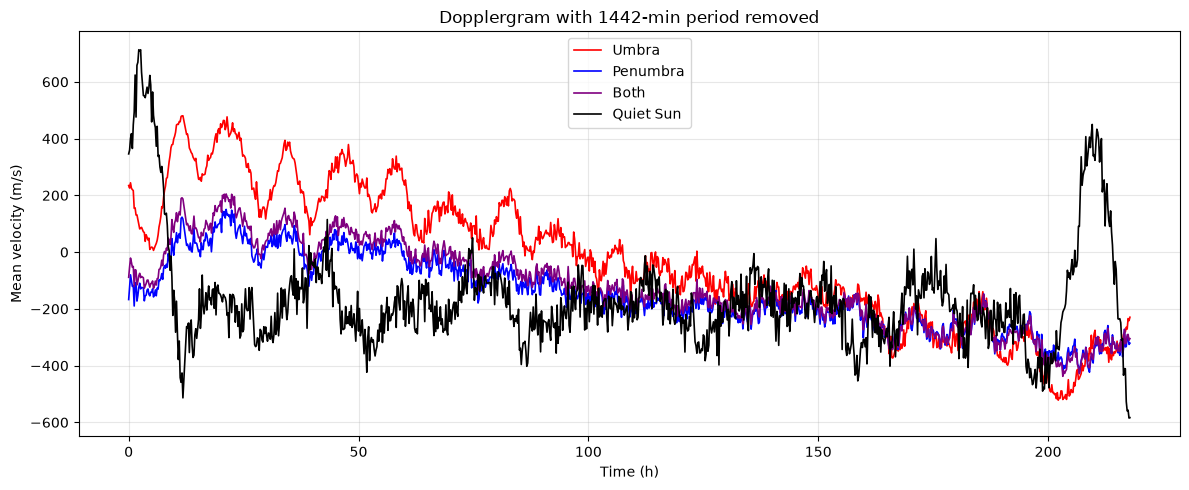

In [40]:
dop_overall_means = plot_dop_filtered(
    data,
    metrics,
    period_min=1442
)

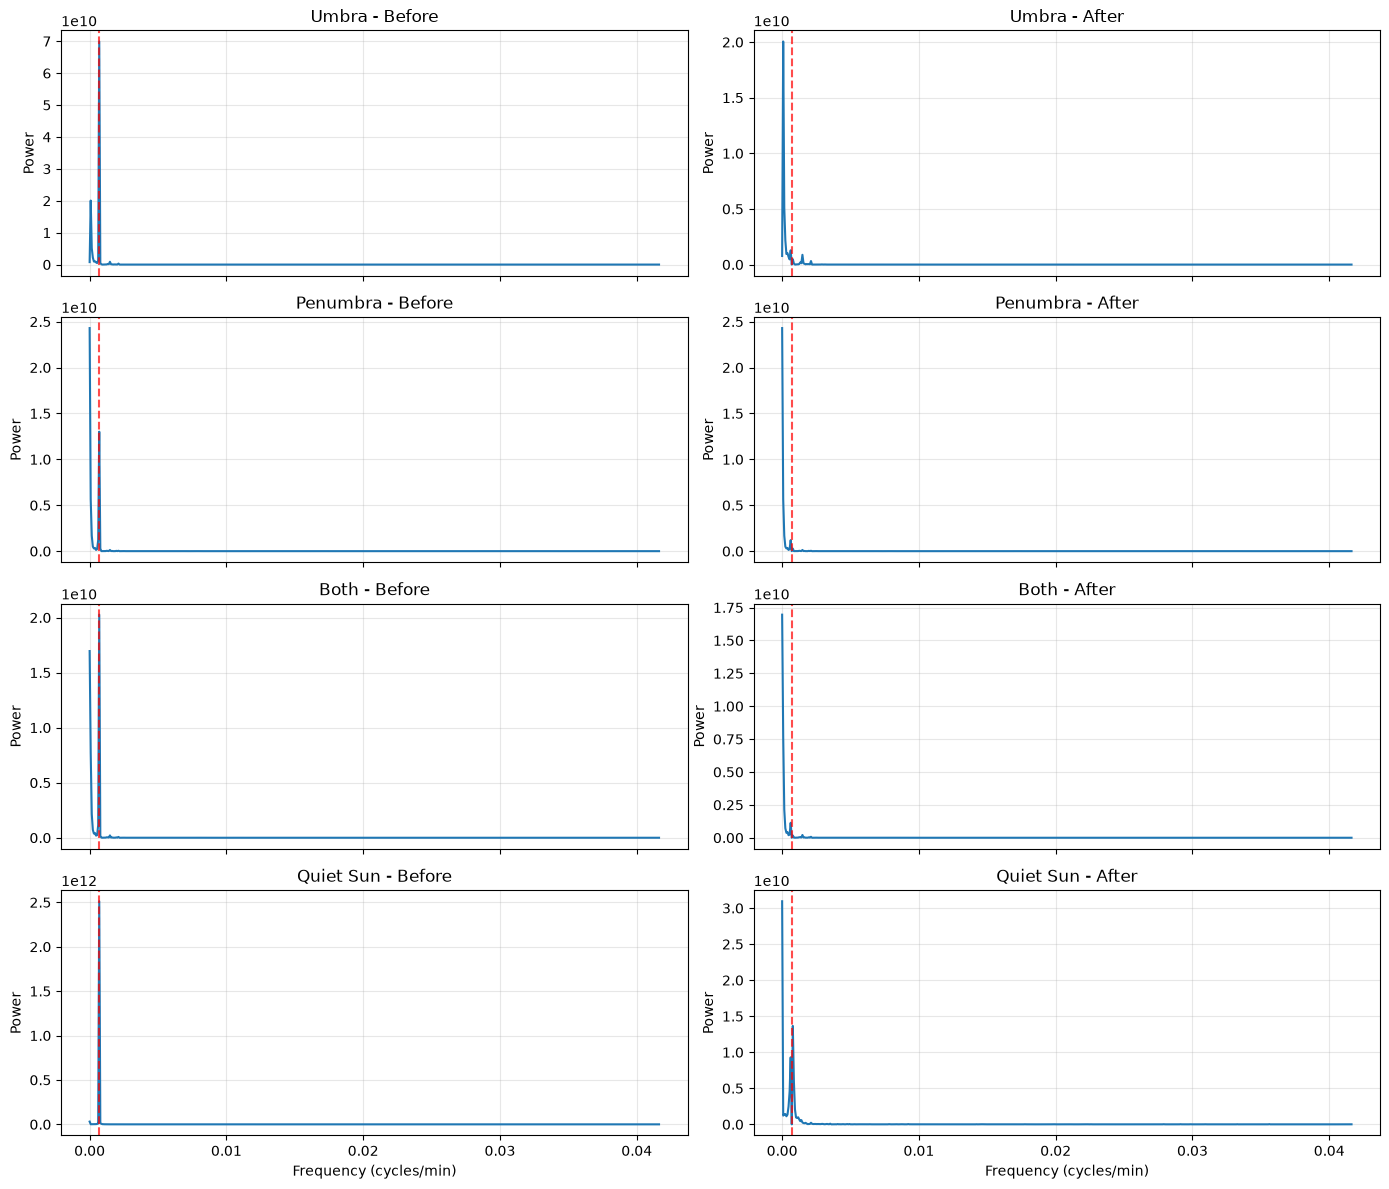

In [41]:
plot_power_spectra_before_after(
    data,
    metrics,
    period_min=1442
)

In [42]:
def plot_mu_means(ds_dir, data, fill=1e6):

    with fits.open(pathlib.Path(ds_dir) / 'cube_mu.fits') as hdul:
        cube_mu = hdul[0].data.astype(float)

    cube_mu = np.where(np.abs(cube_mu) > fill, np.nan, cube_mu)

    regions = {
        'umb': 'Umbra',
        'pen': 'Penumbra',
        'both': 'Both',
    }

    masks = {
        'umb': data['umbra'],
        'pen': data['penumbra'],
        'both': data['both'],
    }

    colors = {
        'umb': 'red',
        'pen': 'blue',
        'both': 'purple',
    }

    time_h = data['time_h']
    n_t = data['n_t']

    mu_means = {}

    fig, ax = plt.subplots(figsize=(10, 5))

    for r, label in regions.items():

        mask = masks[r]

        mean_mu = np.array([
            np.nanmean(cube_mu[t][mask[t]]) if mask[t].any() else np.nan
            for t in range(n_t)
        ])

        mu_means[label] = mean_mu

        ax.plot(time_h, mean_mu, color=colors[r], lw=0.8, label=label)

    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Mean mu')
    ax.set_title('Mean mu (heliocentric angle cosine) vs time')

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return mu_means


def fit_quadratic_mu(data, mu_means):

    time_h = data['time_h']

    coeffs_by_region = {}

    for label, series in mu_means.items():

        coeffs = np.polyfit(time_h, series, 2)
        coeffs_by_region[label] = coeffs

        print(f'{label:<10}: a={coeffs[0]:.6e}  b={coeffs[1]:.6e}  c={coeffs[2]:.6e}')

    return coeffs_by_region


In [43]:
mu_means = plot_mu_means(raw_dir_01, data)


NameError: name 'fits' is not defined

In [ ]:
mu_coeffs = fit_quadratic_mu(data, mu_means)


Umbra     : a=-4.210626e-05  b=8.995862e-03  c=4.910900e-01
Penumbra  : a=-4.220828e-05  b=9.024011e-03  c=4.891839e-01
Both      : a=-4.220977e-05  b=9.024405e-03  c=4.891737e-01


## Step 12 — Normalized mu fit vs magnetogram fit

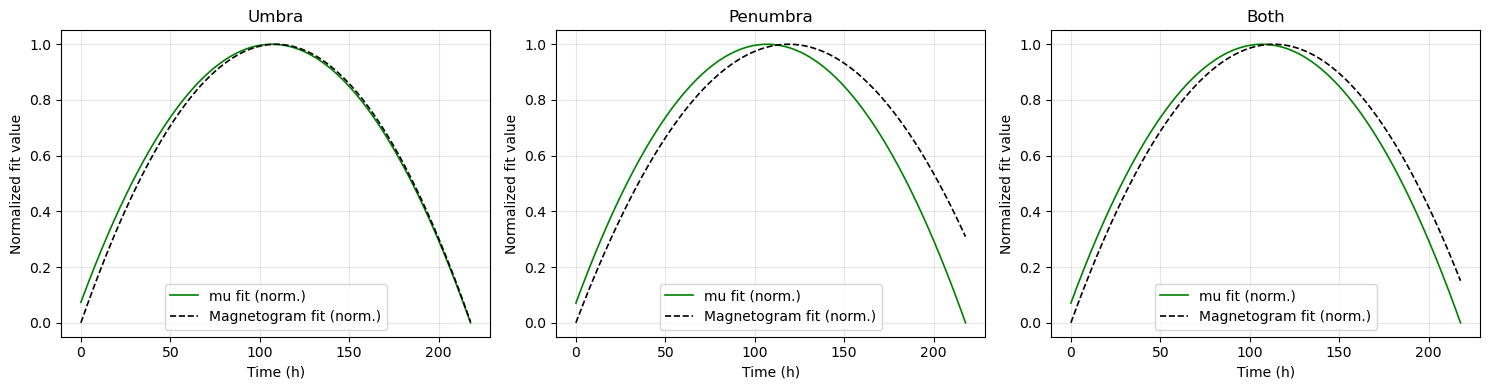

In [ ]:
mu_fits = {label: np.polyval(coeffs, time_h) for label, coeffs in mu_coeffs.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, label in zip(axes, ['Umbra', 'Penumbra', 'Both']):
    ax.plot(time_h, normalize(mu_fits[label]), color='green', lw=1.2, label='mu fit (norm.)')
    ax.plot(time_h, normalize(parab_fits[label]), color='black', lw=1.2, ls='--', label='Magnetogram fit (norm.)')
    ax.set_title(label)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Normalized fit value')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
